In [100]:
from helpers import *

import os
import re
import numpy as np
import matplotlib. pyplot as plt
from scipy.spatial.distance import directed_hausdorff

In [101]:
nubmer_points_list= [100, 200,300,400,500,600,700,800,900,1000,1100,1200, 1300,1400,1500]
n_runs= [10]

In [102]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [103]:
# import math

# def calculate_distance(point1, point2):
#     return math.sqrt((point2[0] - point1[0]) ** 2 + (point2[1] - point1[1]) ** 2)

# def count_repeated_points(points):
#     n = len(points)
#     ep = 1 / (n - 1)  # Threshold for determining if points are distinct
#     clusters = []

#     for i in range(n):
#         found_cluster = False
#         for cluster in clusters:
#             for point in cluster:
#                 if calculate_distance(points[i], point) < ep:
#                     cluster.append(points[i].tolist())
#                     found_cluster = True
#                     break
#             if found_cluster:
#                 break
#         if not found_cluster:
#             clusters.append([points[i].tolist()])

    
#     res= [i[0] for i in clusters]
#     return len(clusters),np.array(res)

# Sample set of points (with duplicates)
# points = [
#     (1.1234567, 2.1234567), 
#     (3.1234567, 4.1234567), 
#     (1.123456, 2.123456), 
#     (5.654321, 6.654321), 
#     (1.1234567, 2.1234567)
# ]

# Get clusters of similar points
# num,clusters = count_repeated_points(points)

# Print the clusters
# print("Clusters of similar points:")
# for i, cluster in enumerate(clusters):
#     print(f"Cluster {i}: {cluster}")


In [104]:
def KS_Test(data, algo):
    
    # Perform K-S test
    ks_statistic, p_value = stats.kstest(data, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)
    
    print("********START********")
    # Display the results
    print("******KS-Test for {}".format(algo),"*********")
    print(f"K-S Statistic: {ks_statistic}")
    print(f"P-Value: {p_value}")

    # Decision based on the p-value
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
    else:
        print("Reject the null hypothesis: The sample does not follow the uniform distribution.")
    
    print("********END********")

# GSM

In [105]:
main_path = "../GSM/solns_runs/Ex4/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]


## Number of starting points vs. PDP and HD

In [106]:
# Folders
# folders= {"n_runs_5":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_10":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_15":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list],
#          "n_runs_20":["../GSM/solns_runs/Ex1/N_{}/n_runs_5".format(str(pt)) for pt in nubmer_points_list]}

folders= ["../GSM/solns_runs/Ex4/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../GSM/solns_runs/Ex4/N_100/',
 '../GSM/solns_runs/Ex4/N_200/',
 '../GSM/solns_runs/Ex4/N_300/',
 '../GSM/solns_runs/Ex4/N_400/',
 '../GSM/solns_runs/Ex4/N_500/',
 '../GSM/solns_runs/Ex4/N_600/',
 '../GSM/solns_runs/Ex4/N_700/',
 '../GSM/solns_runs/Ex4/N_800/',
 '../GSM/solns_runs/Ex4/N_900/',
 '../GSM/solns_runs/Ex4/N_1000/',
 '../GSM/solns_runs/Ex4/N_1100/',
 '../GSM/solns_runs/Ex4/N_1200/',
 '../GSM/solns_runs/Ex4/N_1300/',
 '../GSM/solns_runs/Ex4/N_1400/',
 '../GSM/solns_runs/Ex4/N_1500/']

In [107]:
# folders['n_runs_5']

In [108]:
import os

def list_txt_files_in_directory(directory_path):
#     try:
#         # List all files and directories in the specified path
    files_and_directories = os.listdir(directory_path)
#     print(directory_path)
    # Filter and print only .txt files
    txt_files = [file for file in files_and_directories if file.endswith('.txt')]
    txt_files = [file for file in txt_files if '.txt' in file]
    txt_files.sort()
    txt_files= [directory_path+"/"+file for file in txt_files]
        
    return txt_files

In [109]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
# #         setX = np.random.uniform(low=0.0, high=1.0, size = num_points)
# #         setY = np.random.uniform(low=0.0, high=1.0, size = num_points)

#         t_values = np.random.uniform(9.0, 10, num_points-1)

#         points = np.column_stack((t_values, 15 - t_values))
#         points= np.vstack((points, np.array([5.0,9.0])))
        
#         for file in files:
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(len(solns)))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../GSM/solns_runs/Ex4/plot_ex4.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd
n_times= 10
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points= count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        t_values = np.random.uniform(9.0, 10, len(distinct_points)-1)

        points = np.column_stack((t_values, 15 - t_values))
        points= np.vstack((points, np.array([5.0,9.0])))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex4/plot_ex4.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

89 1000
170 2000
280 3000
403 4000
453 5000
559 6000
657 7000
783 8000
899 9000
911 10000
1006 11000
1159 12000
1204 13000
1376 14000
1388 15000


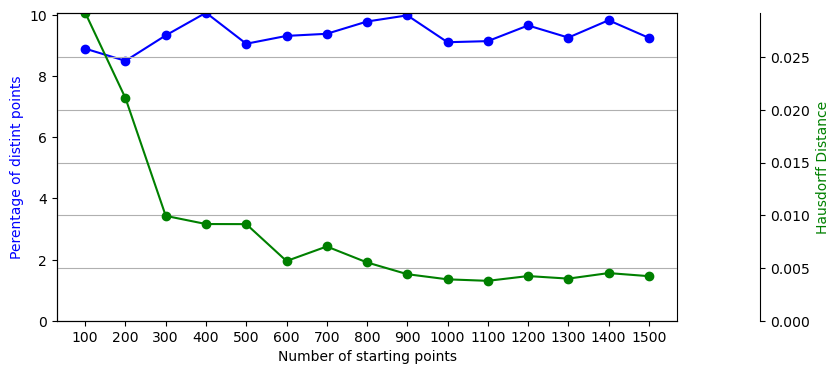

In [110]:
pdpgsm, hdgsm= get_values(folders)

In [111]:
for (p,h) in zip(pdpgsm, hdgsm):
    print(p, " * ", h)

8.9  *  0.029199679541822315
8.5  *  0.02110307237842874
9.333333333333334  *  0.009940326819228488
10.075000000000001  *  0.009165960814659377
9.06  *  0.009158014451102254
9.316666666666666  *  0.005659663309469897
9.385714285714286  *  0.007037729270575111
9.7875  *  0.005525305267787902
9.988888888888889  *  0.004411882093175198
9.11  *  0.003923525083713768
9.145454545454545  *  0.0037814338570063694
9.658333333333333  *  0.004233807511752588
9.26153846153846  *  0.0039919144850670265
9.828571428571427  *  0.004516573417947505
9.253333333333332  *  0.004224226817476983


In [112]:
max(pdpgsm), min(hdgsm)

(10.075000000000001, 0.0037814338570063694)

In [113]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
#             break
            
        all_solns.append(res)
        
    
#     print(np.array(all_solns[0])[:,0])
    
    for i in range(len(all_solns)):
        print("Plot for {} points".format(nubmer_points_list[i]))
#         solns= np.genfromtxt(ex1_path+solutions[i], delimiter=',')
        plt.scatter(np.array(all_solns[i])[:,0], np.array(all_solns[i])[:,1], c= 'black')
        plt.xlim([0,10])
        plt.ylim([0,10])
        plt.grid(True)
        plt.show()
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)

In [114]:
## Plot solution sets
#plot_solns(folders)

In [115]:
# folders
# nubmer_points_list
# T

## Histograms

In [116]:
# n_runs= 50 and 

n_points= nubmer_points_list[np.argmax(pdpgsm)] #1500 
print(n_points)
# Best
directory_path = "../GSM/solns_runs/Ex4/N_{}".format(n_points)
all_solnsgsm= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsgsm.extend(solns.tolist())

all_solnsgsm= np.array(all_solnsgsm)

num, all_solnsgsm = count_repeated_points(all_solnsgsm)
all_solnsgsm= np.array(all_solnsgsm)

400


In [117]:
print(len(all_solnsgsm))

403


In [118]:
def partition_interval(a, b, n):
#     n= n-1
    interval_length = b - a
    partition_width = interval_length / n
    partition_points = [a + i * partition_width for i in range(n + 1)]
    return partition_points

def count_values_in_bins(values, bins):
    # Initialize a dictionary to store the counts for each bin
    bin_counts = {bin_index: 0 for bin_index in range(len(bins) - 1)}

    # Iterate over each value
    for value in values:
        # Find the bin that the value falls into
        bin_index = 0
        while bin_index < len(bins) - 1 and not (bins[bin_index] <= value < bins[bin_index + 1]):
            bin_index += 1

        # Increment the count for the corresponding bin.
        if bin_index < len(bins) - 1:
            bin_counts[bin_index] += 1

    return bin_counts

## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsgsm.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 15-x
y_min = np.min(y)
y_max = np.max(y)
# y

xgsm= x.copy()
ygsm= y.copy()

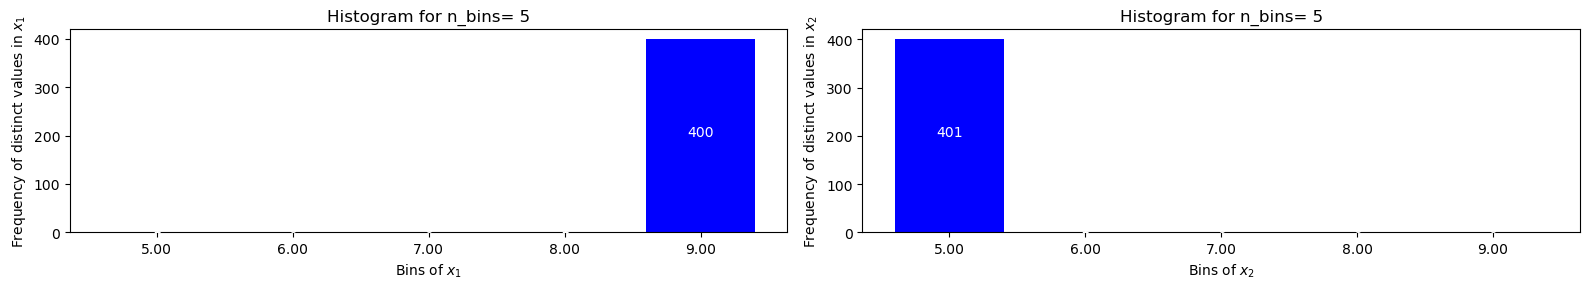

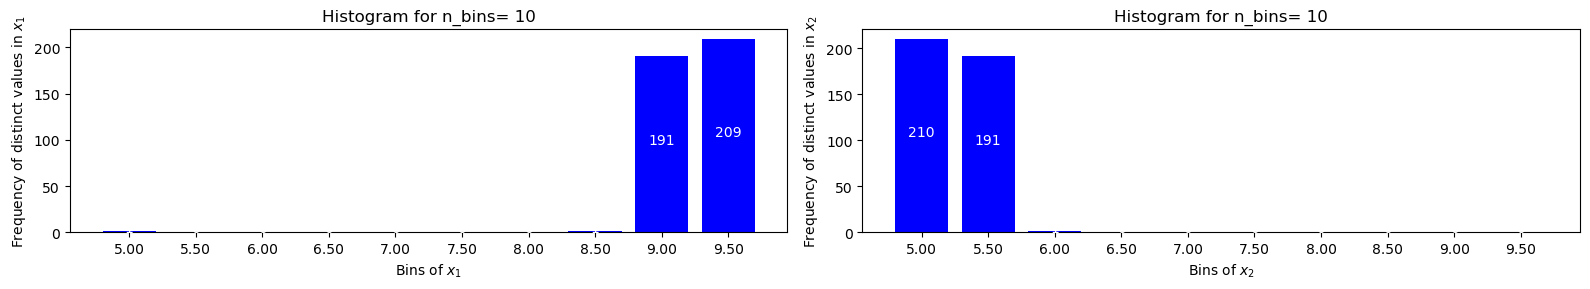

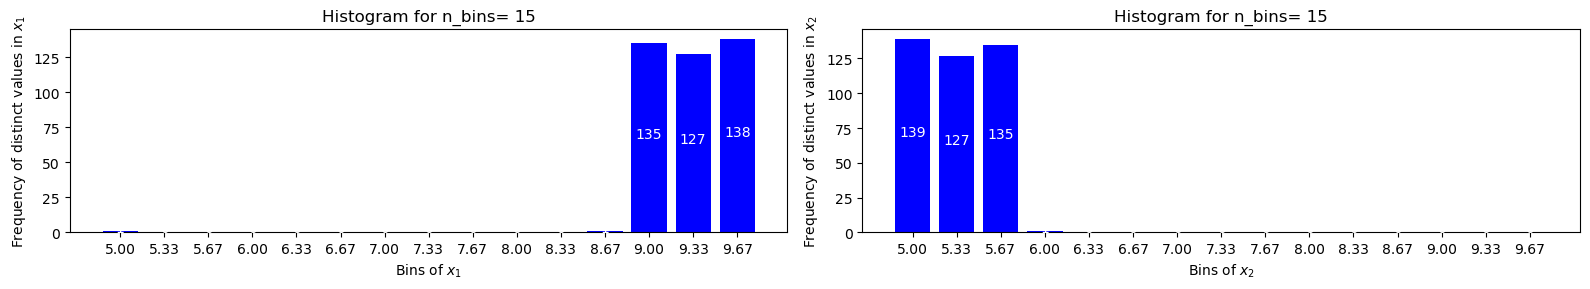

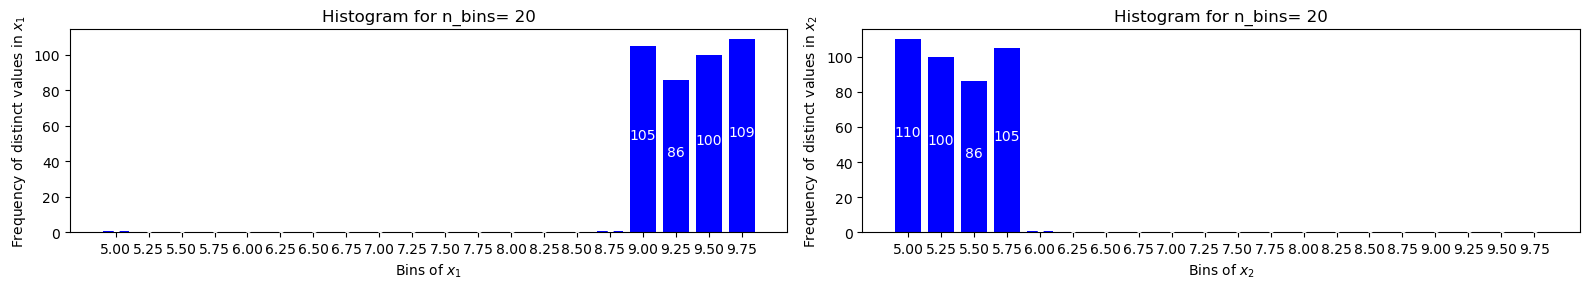

In [119]:
x_hist_gsm= []
y_hist_gsm= []
y_part_gsm= []
x_part_gsm= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_gsm.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_gsm.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_gsm.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_gsm.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../GSM/solns_runs/Ex4/'+'ex4_gsm_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF

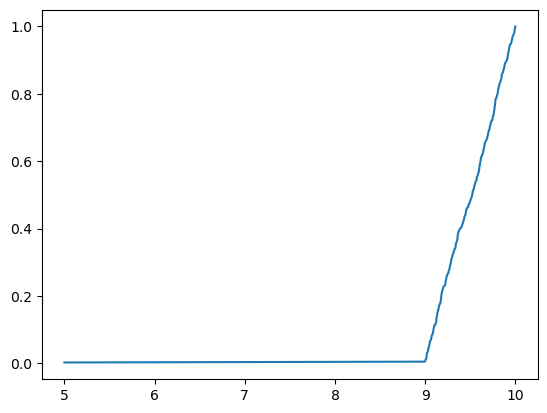

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib import pyplot
from numpy.random import normal
from numpy import hstack
from statsmodels.distributions.empirical_distribution import ECDF
# fit a cdf
ecdf = ECDF(xgsm)
plt.plot(ecdf.x, ecdf.y)
plt.show()


def get_cdf_of_uniform(x, a, b):
    if x<a:
        return 0
    elif a<=x<b:
        return (x-a)/(b-a)
    elif x>b:
        return 1

## KS-Test

In [121]:
import numpy as np
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
data = np.random.uniform(0,1, size=100)

# Perform KS test against a normal distribution (null hypothesis)
ks_statistic, p_value = stats.kstest(data, 'norm')

# Print the results
print(f"KS Statistic: {ks_statistic}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis that the data is normally distributed.")
else:
    print("Cannot reject the null hypothesis that the data is normally distributed.")


KS Statistic: 0.5018732170965315
P-value: 7.902176095057781e-24
Reject the null hypothesis that the data is normally distributed.


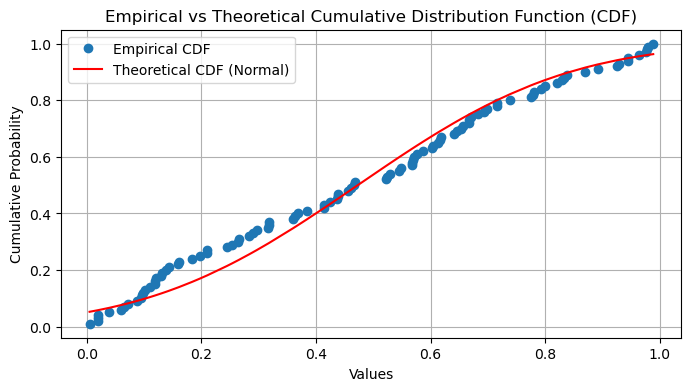

In [122]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data (replace with your actual data)
np.random.seed(0)
# data = np.random.normal(loc=0, scale=1, size=100)

# Sort the data
sorted_data = np.sort(data)

# Calculate the empirical CDF
n = sorted_data.size
y_empirical = np.arange(1, n+1) / n

# Calculate the theoretical CDF (normal distribution)
mean, std = np.mean(data), np.std(data)
y_theoretical = stats.norm.cdf(sorted_data, loc=mean, scale=std)

# Plotting the empirical and theoretical CDFs
plt.figure(figsize=(8, 4))
plt.plot(sorted_data, y_empirical, label='Empirical CDF', marker='o', linestyle='none')
plt.plot(sorted_data, y_theoretical, label='Theoretical CDF (Normal)', color='red')
plt.xlabel('Values')
plt.ylabel('Cumulative Probability')
plt.title('Empirical vs Theoretical Cumulative Distribution Function (CDF)')
plt.legend()
plt.grid(True)
plt.show()


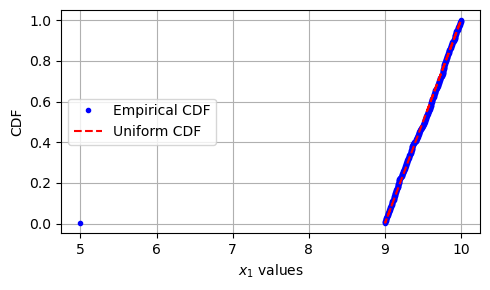

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [123]:
# KS Test on x: 
a,b= 9.0,10.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5.0))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xgsm)
ecdf_gsm_x = ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_x.x, ecdf_gsm_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
plt.plot([5.0],[1], 'r--')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xgsm, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [124]:
ecdf_gsm_x.y

array([0.        , 0.00248139, 0.00496278, 0.00744417, 0.00992556,
       0.01240695, 0.01488834, 0.01736973, 0.01985112, 0.02233251,
       0.0248139 , 0.02729529, 0.02977667, 0.03225806, 0.03473945,
       0.03722084, 0.03970223, 0.04218362, 0.04466501, 0.0471464 ,
       0.04962779, 0.05210918, 0.05459057, 0.05707196, 0.05955335,
       0.06203474, 0.06451613, 0.06699752, 0.06947891, 0.0719603 ,
       0.07444169, 0.07692308, 0.07940447, 0.08188586, 0.08436725,
       0.08684864, 0.08933002, 0.09181141, 0.0942928 , 0.09677419,
       0.09925558, 0.10173697, 0.10421836, 0.10669975, 0.10918114,
       0.11166253, 0.11414392, 0.11662531, 0.1191067 , 0.12158809,
       0.12406948, 0.12655087, 0.12903226, 0.13151365, 0.13399504,
       0.13647643, 0.13895782, 0.14143921, 0.1439206 , 0.14640199,
       0.14888337, 0.15136476, 0.15384615, 0.15632754, 0.15880893,
       0.16129032, 0.16377171, 0.1662531 , 0.16873449, 0.17121588,
       0.17369727, 0.17617866, 0.17866005, 0.18114144, 0.18362

In [125]:
ecdf_gsm_x.x

array([       -inf,  5.00000435,  8.99813533,  9.00113428,  9.00354077,
        9.00747271,  9.01408488,  9.0146832 ,  9.01559876,  9.01603664,
        9.01670914,  9.01824654,  9.01986749,  9.0249723 ,  9.02975863,
        9.03267354,  9.03373828,  9.03512261,  9.035539  ,  9.04041925,
        9.04252109,  9.04641245,  9.04737251,  9.0479925 ,  9.05170413,
        9.05197628,  9.05457188,  9.05608431,  9.06558032,  9.06679875,
        9.06756365,  9.06861899,  9.07250284,  9.07398825,  9.07718656,
        9.08352668,  9.08481345,  9.08800323,  9.08911426,  9.09169641,
        9.09275094,  9.09403679,  9.0948635 ,  9.09772282,  9.09814106,
        9.10050963,  9.11301879,  9.11348222,  9.11833439,  9.1225307 ,
        9.12371843,  9.12395669,  9.12435181,  9.12462822,  9.12531109,
        9.1275293 ,  9.13109301,  9.1329327 ,  9.13323702,  9.13404792,
        9.13486869,  9.13824528,  9.14021411,  9.14199078,  9.14439659,
        9.15014826,  9.15057447,  9.15082645,  9.15393922,  9.15

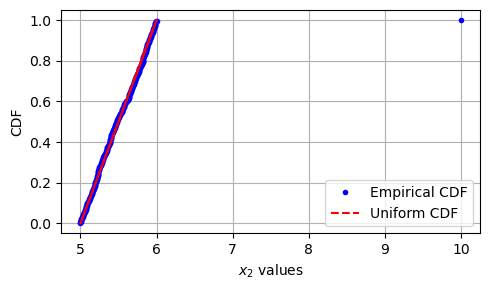

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [126]:
# KS Test on y: 
# Number of samples
a,b= 5.0, 6.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(x)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ygsm)
ecdf_gsm_y = ECDF(ygsm) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../GSM/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ygsm, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [127]:
def plot_solns(folders):
    all_solns= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        res= []
        for file in files:
            solns= np.genfromtxt(file, delimiter=',')
            num, distinct_points = count_repeated_points(solns)
            distinct_points= np.array(distinct_points)
            res.extend(distinct_points.tolist())
            
        all_solns.append(res)

    return all_solns

data_gsm= plot_solns(folders)

# PVI

In [128]:
# New

def constraint_function(x):
    return 15-(x[0]+x[1])
## Load data

import json

# with open('../Scripts/PVI/Ex3PVI.json') as f:
#     data= json.load(f)

with open('../Scripts/PVI/Ex4PVIT.json') as f:
    dataT= json.load(f)

T_list= [1, 2, 3, 4, 5]
data_dict= dict.fromkeys(range(1, len(T_list)+1), 0)

data_dict



for T in T_list:
    data_all= []

    for i in range(len(nubmer_points_list)):
        res_= []

        if len(dataT[str(T)][i])== 0:
            # print(dataT[str(1)][i])
            data_all.append([dataT[str(T)][i]])
            # res_.append([dataT[str(1)][i]])
        else:
            
            for t in range(len(dataT[str(T)][i])):
                #print(data[str(i)][t])
                if np.abs(constraint_function(dataT[str(T)][i][t]))<= 1e-6:
                    res_.append(dataT[str(T)][i][t])
            data_all.append(res_)
    data_dict[T]= data_all


res_all= []

for i in range(len(nubmer_points_list)):
    res= []
    for T in T_list:
        res.extend(data_dict[T][i])

    res_all.append(res)

In [129]:
data_all= res_all

In [130]:
data_all[0]

[[9.707582780704243, 5.292417219295757],
 [9.881650284860237, 5.118349715139763],
 [9.791193377710783, 5.208806622289217],
 [9.187702457549236, 5.812297542450765],
 [9.917386895372708, 5.082613104627293],
 [9.137317872944216, 5.862682127055784],
 [9.792183693710173, 5.207816306289827],
 [9.820866885294244, 5.179133114705756],
 [9.291625129770084, 5.708374870229916],
 [9.331468170095008, 5.6685318299049925],
 [9.803595452171875, 5.196404547828124],
 [9.251323948943554, 5.748676051056446],
 [9.902293288136327, 5.097706711863672],
 [9.9668483869155, 5.0331516130845015],
 [9.998971110932143, 5.001028889067857],
 [9.931336521466955, 5.068663478533045],
 [9.833582001573669, 5.166417998426331],
 [9.9248263223293, 5.075173677670699],
 [9.93738543518338, 5.062614564816621],
 [9.994176329157266, 5.005823670842733],
 [9.93120773231467, 5.068792267685329],
 [9.939142272652216, 5.060857727347783],
 [9.521027755423933, 5.478972244576066],
 [8.933876822117382, 6.066123177882619],
 [9.919001703300074,

In [131]:
data= []
dist_= []
avg_hd= []

for (idx, pt) in enumerate(nubmer_points_list):
    dt= []
    
    
    num_points= nubmer_points_list[idx]
    
    t_values = np.random.uniform(9.0, 10, num_points-1)

    points = np.column_stack((t_values, 15 - t_values))
    points= np.vstack((points, np.array([5.0,9.0])))
    
    
        
    num, distinct_points = count_repeated_points(np.array(data_all[idx]))
    distinct_points= np.array(distinct_points)    
    
    hausdorff_distance = directed_hausdorff(np.array(data_all[idx]), points)[0]
    dist_.append((len(distinct_points)/(len(data_all[idx])))*100)
    avg_hd.append(hausdorff_distance)

In [132]:
dist_

[54.66321243523316,
 51.70842824601367,
 54.145516074450086,
 53.38822039265357,
 54.00291120815138,
 52.78934221482098,
 52.31265686626031,
 51.2258064516129,
 51.89636752136752,
 52.3352688714971,
 52.38979118329466,
 52.1533072326396,
 53.03088067098742,
 52.988338192419825,
 52.66689030526669]

In [133]:
avg_hd

[0.8337487223461976,
 0.8044059069896133,
 0.8792168497950971,
 0.9161956420985472,
 0.9234634913196472,
 0.8829333042402339,
 0.932095633915626,
 0.8917074539917572,
 0.9437310946449342,
 1.0000641339442424,
 0.9773606133249356,
 0.9164618633494731,
 0.9712975237466038,
 0.92483644071235,
 0.9268473998172884]

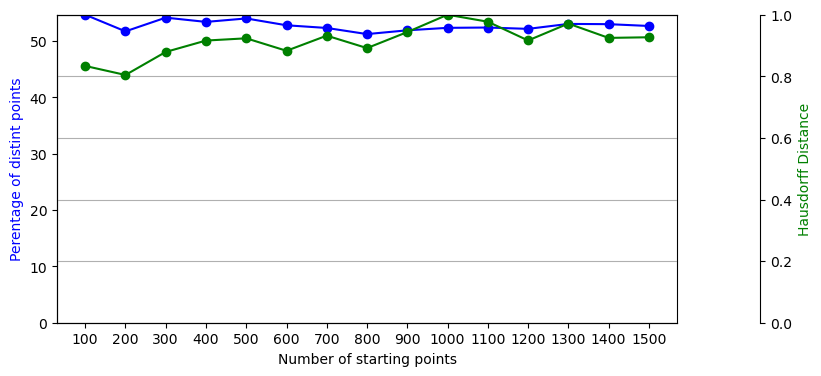

In [134]:
fig, ax1 = plt.subplots(figsize=(8, 4))

# Create second axis with different scale
ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
ax1.set_ylim([0.0, np.max(dist_)])
ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


# Create third axis with different scale
ax2 = ax1.twinx()
ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
ax2.plot(nubmer_points_list, avg_hd, 'go-')
ax2.set_ylabel('Hausdorff Distance', color='g')
ax2.set_ylim([0.0, np.max(avg_hd)])

xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
ax1.set_xticks(xticks)
ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


plt.savefig('../PVI/solns_runs/Ex4/plot_ex4.png')
plt.grid(True)
plt.show()

In [135]:
def calculate_distance(point1, point2):
    return sum((x - y) ** 2 for x, y in zip(point1, point2)) ** 0.5

def calculate_tolerance(points):
    num_points = len(points)
    tolerance = 1/num_points
    return tolerance
    
def count_repeated_points(points):
    #points = points[np.lexsort((points[:, 1], points[:, 0]))]
    #n= len(points)
    ep=  calculate_tolerance(points)
    distinct_points = []

    for point in points:
        is_distinct = True
        for distinct_point in distinct_points:
            if calculate_distance(point, distinct_point) < ep:
                is_distinct = False
                break
        if is_distinct:
            distinct_points.append(point)
            
    return len(distinct_points), distinct_points

In [136]:
# plot_sol`ns(folders)

In [137]:
for i in range(len(data_all)):
    print(len(data_all[i]))

386
878
1182
1579
2061
2402
2789
3100
3744
3961
4310
4853
5246
5488
5962


In [138]:
pdppvi, hdgpvi= dist_.copy(),avg_hd.copy()

In [139]:
hdgpvi

[0.8337487223461976,
 0.8044059069896133,
 0.8792168497950971,
 0.9161956420985472,
 0.9234634913196472,
 0.8829333042402339,
 0.932095633915626,
 0.8917074539917572,
 0.9437310946449342,
 1.0000641339442424,
 0.9773606133249356,
 0.9164618633494731,
 0.9712975237466038,
 0.92483644071235,
 0.9268473998172884]

In [140]:
max(dist_), min(avg_hd)

(54.66321243523316, 0.8044059069896133)

In [141]:
# Best npoint
n_points= nubmer_points_list[np.argmax(pdppvi)] # 1500
sol= np.array(data_all[-1])
print(sol)

[[9.52478263 5.47521737]
 [9.39773975 5.60226025]
 [9.68426025 5.31573975]
 ...
 [9.91994147 5.08005853]
 [9.98984581 5.01015419]
 [9.89386204 5.10613796]]


In [142]:
len(sol)

5962

Plot for 100 points


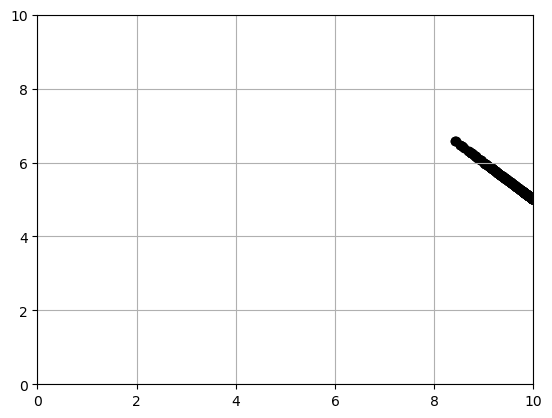

Plot for 200 points


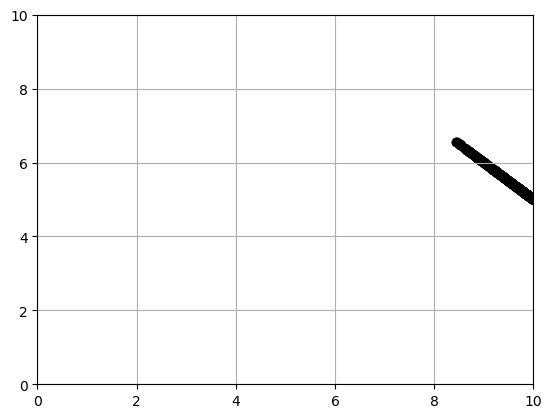

Plot for 300 points


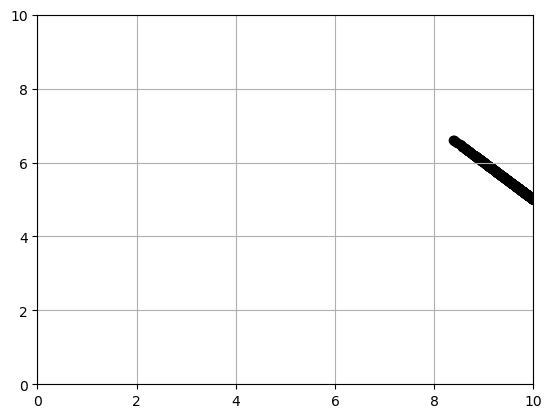

Plot for 400 points


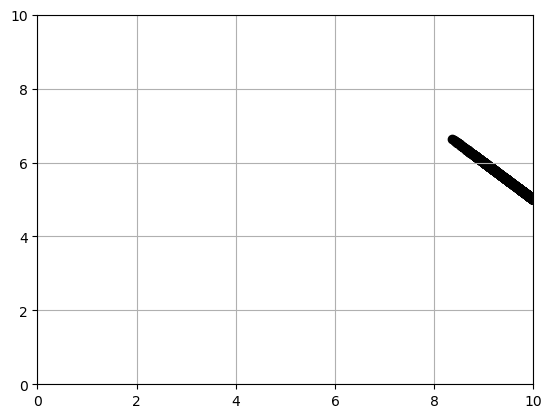

Plot for 500 points


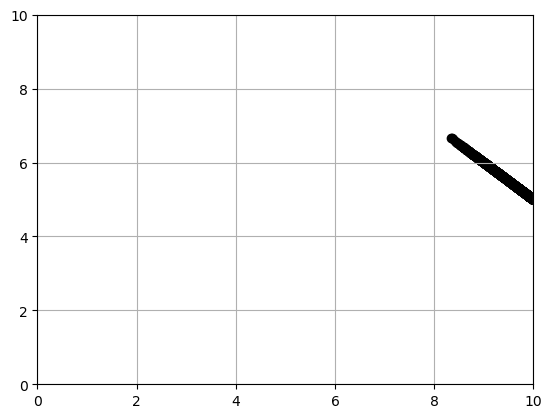

Plot for 600 points


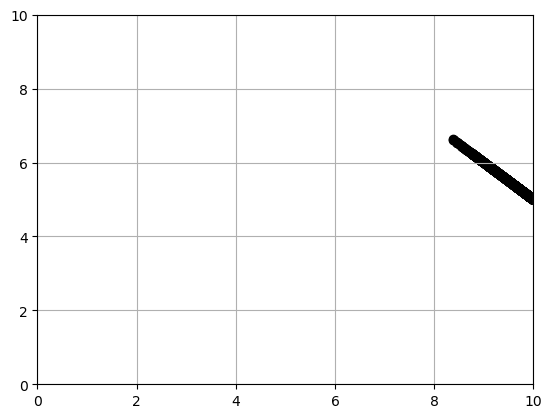

Plot for 700 points


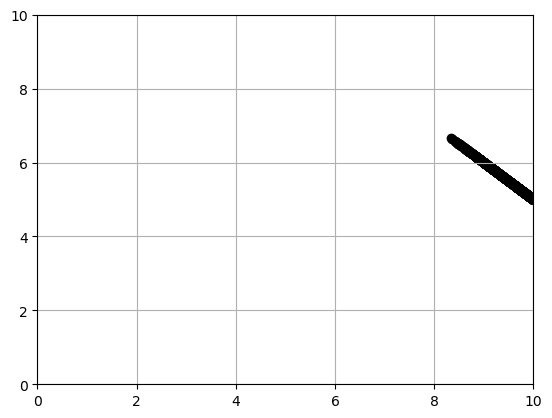

Plot for 800 points


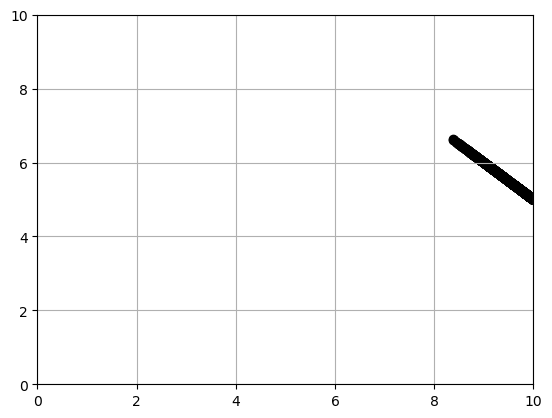

Plot for 900 points


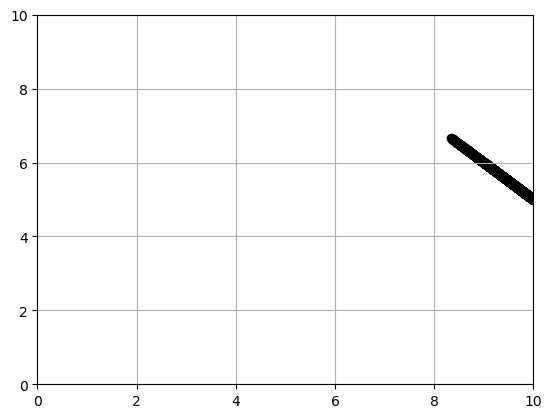

Plot for 1000 points


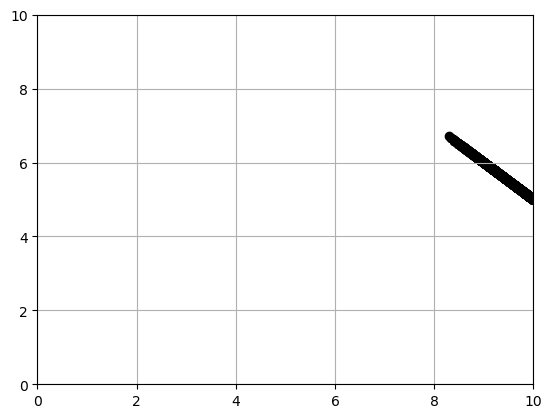

Plot for 1100 points


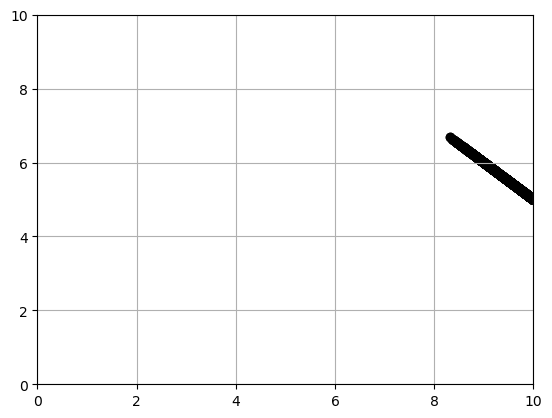

Plot for 1200 points


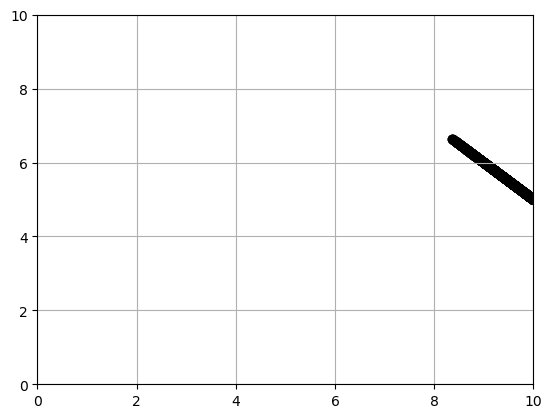

Plot for 1300 points


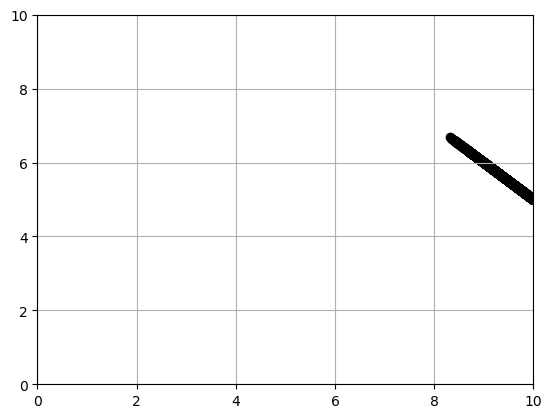

Plot for 1400 points


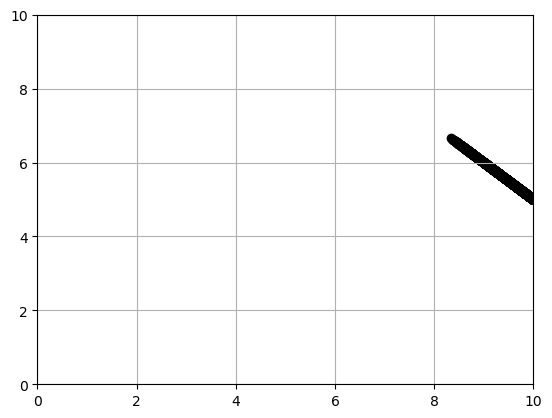

Plot for 1500 points


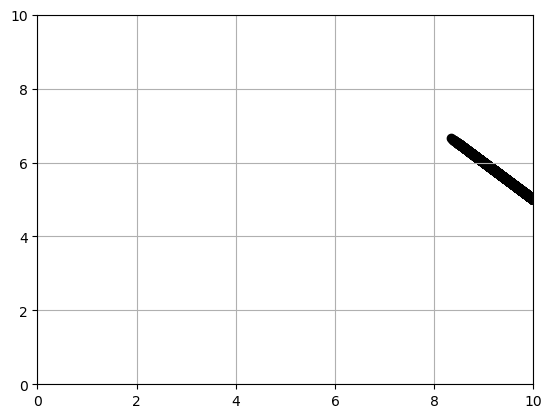

In [143]:
for i in range(len(data_all)):
    print("Plot for {} points".format(nubmer_points_list[i]))
#         solns= np.genfromtxt(ex1_path+solutions[i], delimiter=',')
    plt.scatter(np.array(data_all[i])[:,0], np.array(data_all[i])[:,1], c= 'black')
    plt.xlim([0,10])
    plt.ylim([0,10])
    plt.grid(True)
    plt.show()

## Metrics with all points

In [144]:
len(data_all)

15

## Histogram

In [145]:
sol

array([[9.52478263, 5.47521737],
       [9.39773975, 5.60226025],
       [9.68426025, 5.31573975],
       ...,
       [9.91994147, 5.08005853],
       [9.98984581, 5.01015419],
       [9.89386204, 5.10613796]])

In [146]:
## x:
bins_list= [5, 10, 15, 20]
solns= sol.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 15-x
y_min = np.min(y)
y_max = np.max(y)
# y

xpvi= x.copy()
ypvi= y.copy()

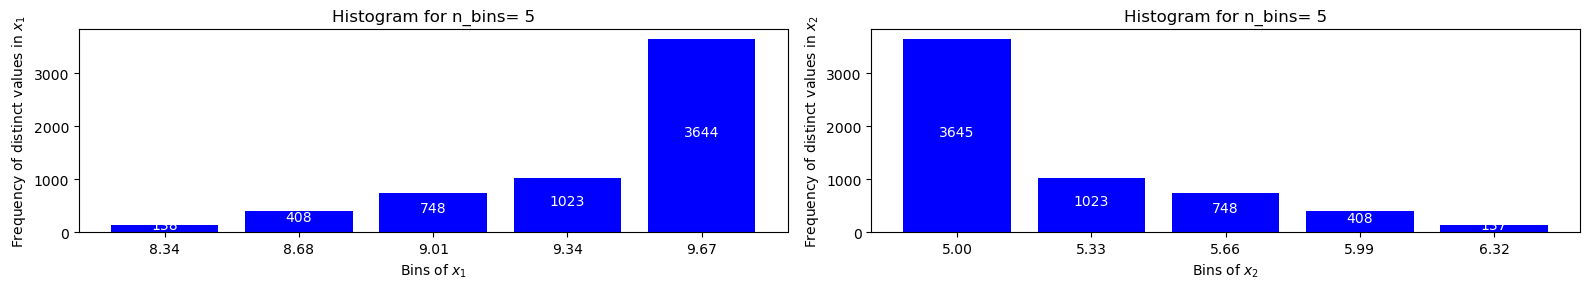

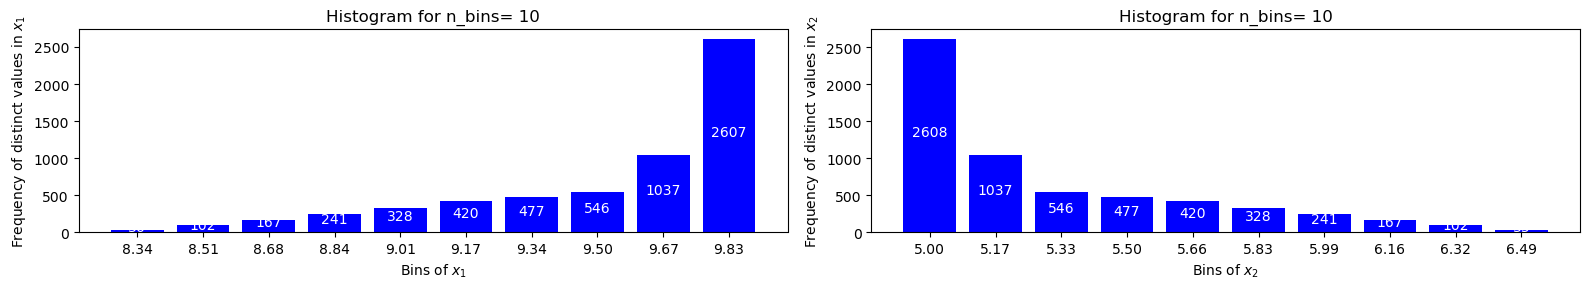

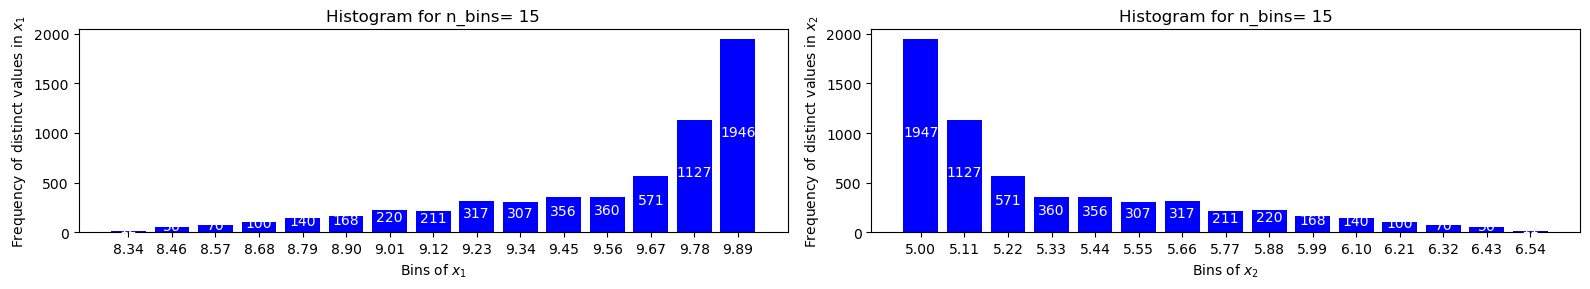

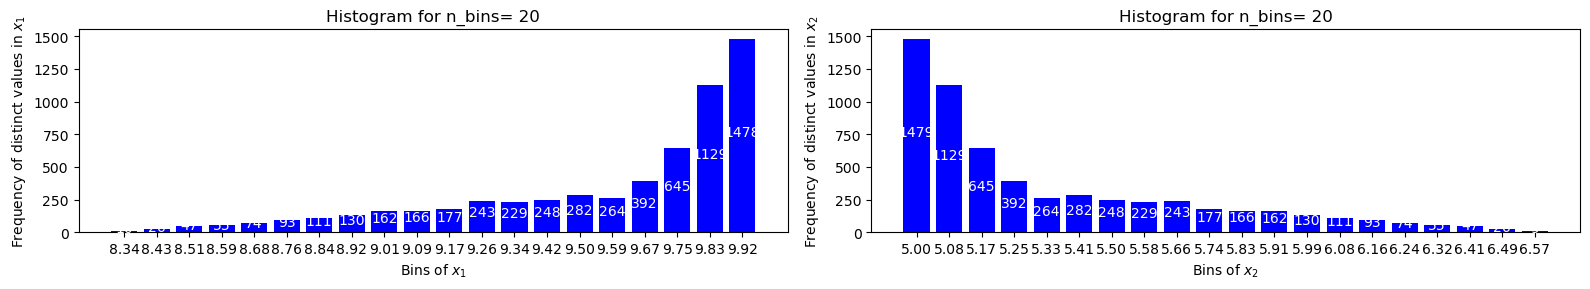

In [147]:
x_hist_pvi= []
y_hist_pvi= []
y_part_pvi= []
x_part_pvi= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_pvi.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_pvi.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_pvi.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_pvi.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../PVI/solns_runs/Ex4/'+'ex4_pvi_hist'+str(n_bins)+'.png')
    plt.show()

In [148]:
for (p,h) in zip(pdppvi, hdgpvi):
    print(p, " * ", h)

54.66321243523316  *  0.8337487223461976
51.70842824601367  *  0.8044059069896133
54.145516074450086  *  0.8792168497950971
53.38822039265357  *  0.9161956420985472
54.00291120815138  *  0.9234634913196472
52.78934221482098  *  0.8829333042402339
52.31265686626031  *  0.932095633915626
51.2258064516129  *  0.8917074539917572
51.89636752136752  *  0.9437310946449342
52.3352688714971  *  1.0000641339442424
52.38979118329466  *  0.9773606133249356
52.1533072326396  *  0.9164618633494731
53.03088067098742  *  0.9712975237466038
52.988338192419825  *  0.92483644071235
52.66689030526669  *  0.9268473998172884


## Uniform CDF vs. empirical CDF and KS-Test

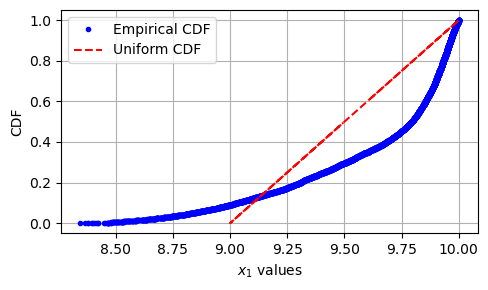

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [149]:
# KS Test on x: 
a,b= 9.0,10.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xpvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xpvi)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xpvi)
ecdf_pvi_x = ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_pvi_x.x, ecdf_pvi_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xpvi, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

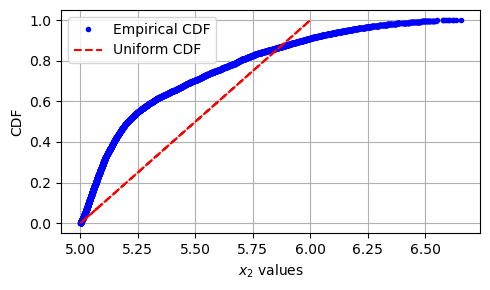

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [150]:
# KS Test on y: 
# Number of samples
a,b= 5.0, 6.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ypvi))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ypvi)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ypvi)
ecdf_gsm_y = ECDF(ypvi) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_gsm_y.x, ecdf_gsm_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../PVI/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ypvi, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")


In [151]:
data_pvi= data_all

### Number of starting points vs. PDP and HD

In [152]:
# pdp, hd= get_values(folders)

# BFGS

In [153]:
def list_subfolders(folder_path):
    subfolders = [f.path for f in os.scandir(folder_path) if f.is_dir()]
    sorted_subfolders = sorted(subfolders, key=lambda x: int(x.split("_")[-1]))
    return sorted_subfolders


def list_txt_files(folder_path):
    txt_files = [f for f in os.listdir(folder_path) if f.endswith('.txt')]
#     txt_files = sorted(txt_files, key=lambda x: int(x.split("_")[2]))
    return txt_files

### Number of starting points vs. PDP and HD

In [154]:
main_path = "../Merit/solns_runs/Ex4/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../Merit/solns_runs/Ex4/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../Merit/solns_runs/Ex4/N_100/',
 '../Merit/solns_runs/Ex4/N_200/',
 '../Merit/solns_runs/Ex4/N_300/',
 '../Merit/solns_runs/Ex4/N_400/',
 '../Merit/solns_runs/Ex4/N_500/',
 '../Merit/solns_runs/Ex4/N_600/',
 '../Merit/solns_runs/Ex4/N_700/',
 '../Merit/solns_runs/Ex4/N_800/',
 '../Merit/solns_runs/Ex4/N_900/',
 '../Merit/solns_runs/Ex4/N_1000/',
 '../Merit/solns_runs/Ex4/N_1100/',
 '../Merit/solns_runs/Ex4/N_1200/',
 '../Merit/solns_runs/Ex4/N_1300/',
 '../Merit/solns_runs/Ex4/N_1400/',
 '../Merit/solns_runs/Ex4/N_1500/']

In [155]:
# xgsm
# ygsm
# ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
# ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
# ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
# ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

In [156]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         t_values = np.random.uniform(9.0, 10, num_points-1)

#         points = np.column_stack((t_values, 15 - t_values))
#         points= np.vstack((points, np.array([5.0,9.0])))
        
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
#             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../Merit/solns_runs/Ex4/plot_ex4.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        t_values = np.random.uniform(9.0, 10, len(distinct_points)-1)

        points = np.column_stack((t_values, 15 - t_values))
        points= np.vstack((points, np.array([5.0,9.0])))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../Merit/solns_runs/Ex4/plot_ex4.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

768 1000
1557 2000
2924 3000
3890 4000
4408 5000
5871 6000
6840 7000
7862 8000
8845 9000
9807 10000
9734 11000
10649 12000
12770 13000
13787 14000
14755 15000


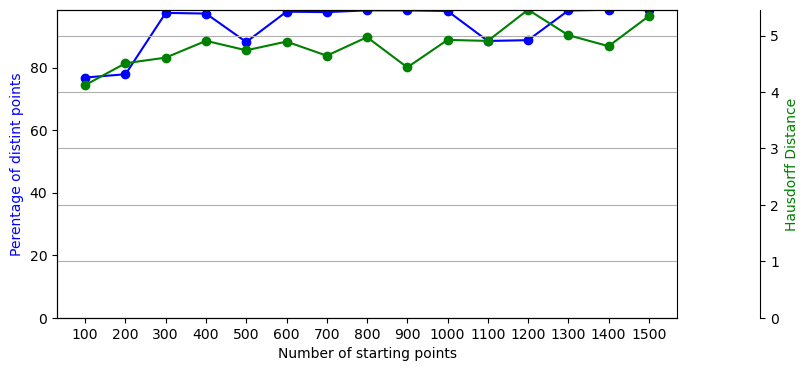

In [157]:
pdpbfgs, hdbfgs= get_values(folders)

In [158]:
for (p,h) in zip(pdpbfgs,hdbfgs):
    print(p, " * ", h)

76.8  *  4.122873467210287
77.85  *  4.510316291430816
97.46666666666667  *  4.609360199673129
97.25  *  4.907223758373593
88.16000000000001  *  4.739308355342699
97.85000000000001  *  4.893999998980722
97.71428571428571  *  4.643814152518616
98.275  *  4.972195168431954
98.27777777777777  *  4.436803547804735
98.07000000000001  *  4.923837560040124
88.49090909090908  *  4.9058401985359055
88.74166666666666  *  5.45855281237149
98.23076923076923  *  5.007356401438547
98.47857142857143  *  4.812640082515669
98.36666666666667  *  5.345583626859765


In [159]:
max(pdpbfgs), min(hdbfgs)

(98.47857142857143, 4.122873467210287)

In [160]:
#plot_solns(folders)

### Histograms

In [161]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpbfgs)] # 150
# Best
directory_path = "../Merit/solns_runs/Ex4/N_{}".format(n_points)
all_solnsbfgs= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnsbfgs.extend(solns.tolist())

all_solnsbfgs= np.array(all_solnsbfgs)

num, all_solnsbfgs = count_repeated_points(all_solnsbfgs)
all_solnsbfgs= np.array(all_solnsbfgs)

In [162]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnsbfgs.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 15-x
y_min = np.min(y)
y_max = np.max(y)
# y

xbfgs= x.copy()
ybfgs= y.copy()

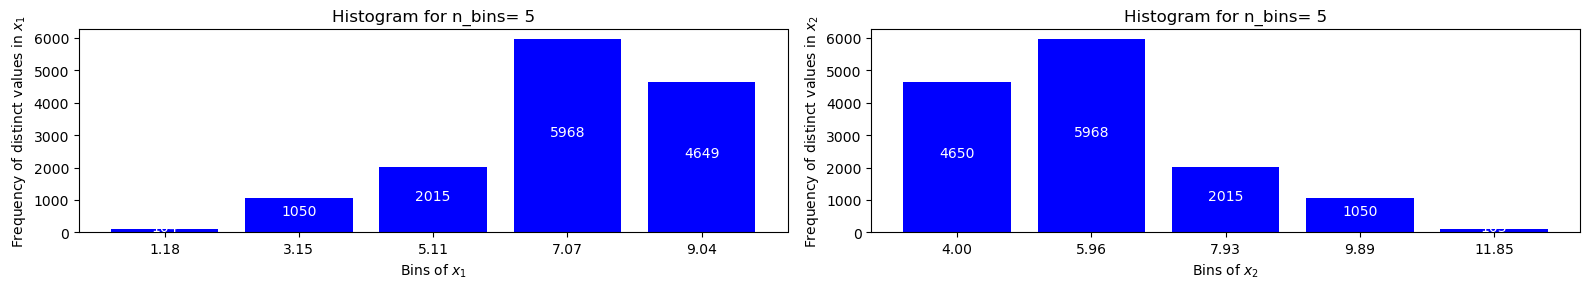

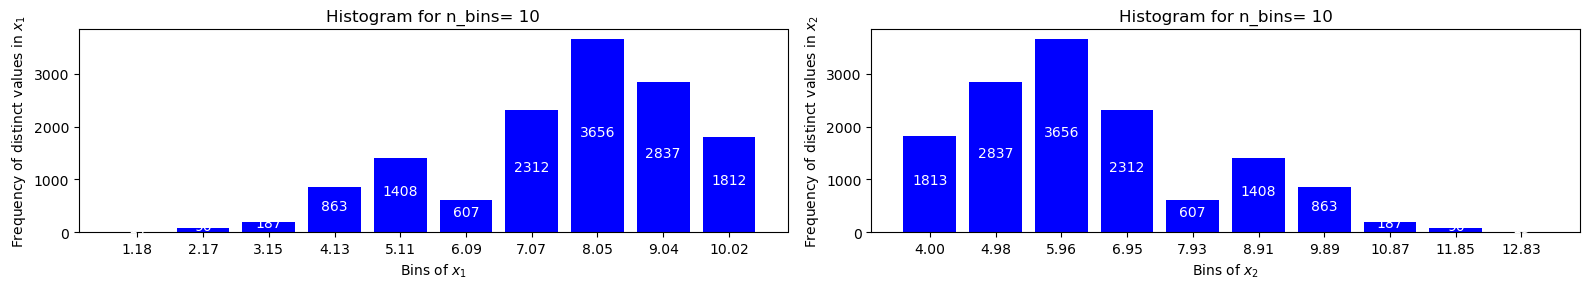

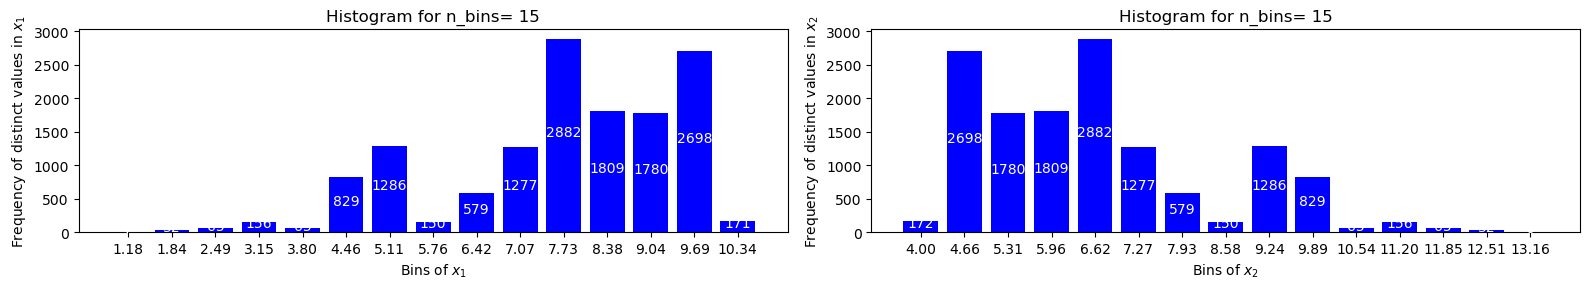

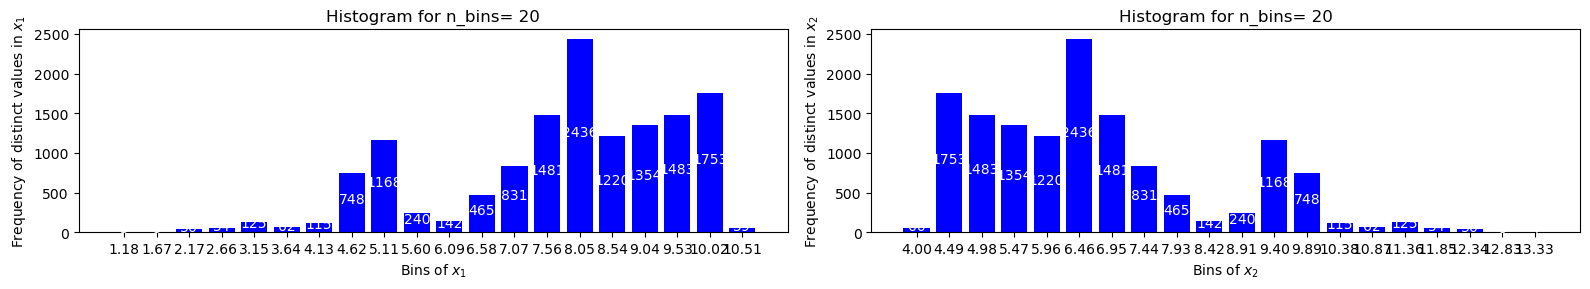

In [163]:
x_hist_bfgs= []
y_hist_bfgs= []
y_part_bfgs= []
x_part_bfgs= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_bfgs.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_bfgs.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_bfgs.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_bfgs.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../Merit/solns_runs/Ex4/'+'ex4_bfgs_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and KS-Test

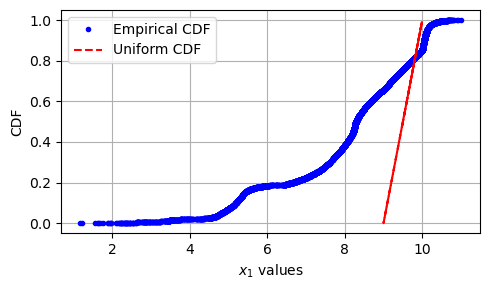

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [164]:
 # KS Test on x: 
a,b= 9.0,10.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xbfgs)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xbfgs)
ecdf_bfgs_x = ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_x.x, ecdf_bfgs_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xbfgs, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

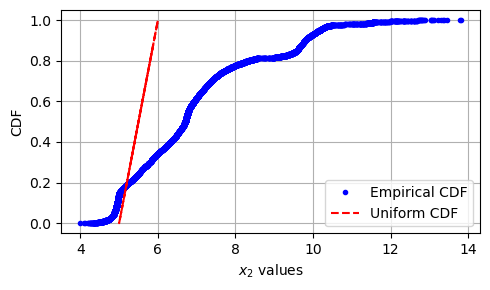

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [165]:
# KS Test on y: 
# Number of samples
a,b= 5.0, 6.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(x))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ybfgs)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ybfgs)
ecdf_bfgs_y = ECDF(ybfgs) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_bfgs_y.x, ecdf_bfgs_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../Merit/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ybfgs, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# EIA

## Number of starting points vs. PDP and HD

In [166]:
main_path = "../EIA/solns_runs/Ex4/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../EIA/solns_runs/Ex4/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../EIA/solns_runs/Ex4/N_100/',
 '../EIA/solns_runs/Ex4/N_200/',
 '../EIA/solns_runs/Ex4/N_300/',
 '../EIA/solns_runs/Ex4/N_400/',
 '../EIA/solns_runs/Ex4/N_500/',
 '../EIA/solns_runs/Ex4/N_600/',
 '../EIA/solns_runs/Ex4/N_700/',
 '../EIA/solns_runs/Ex4/N_800/',
 '../EIA/solns_runs/Ex4/N_900/',
 '../EIA/solns_runs/Ex4/N_1000/',
 '../EIA/solns_runs/Ex4/N_1100/',
 '../EIA/solns_runs/Ex4/N_1200/',
 '../EIA/solns_runs/Ex4/N_1300/',
 '../EIA/solns_runs/Ex4/N_1400/',
 '../EIA/solns_runs/Ex4/N_1500/']

In [167]:
# def get_values(folders):
#     dist_= []
#     avg_hd= []
#     for pt in range(len(nubmer_points_list)):
#         directory_path = folders[pt]

#         files= list_txt_files_in_directory(directory_path)
#         res= []
#         hd= []
        
#         num_points= nubmer_points_list[pt]
#         t_values = np.random.uniform(9.0, 10, num_points-1)

#         points = np.column_stack((t_values, 15 - t_values))
#         points= np.vstack((points, np.array([5.0,9.0])))
        
#         for file in files:
#             if "._" in file:
#                 file= file.replace("._","")
#             solns= np.genfromtxt(file, delimiter=',')
#             num, distinct_points = count_repeated_points(solns)
#             distinct_points= np.array(distinct_points)
            
# #             res.append((len(distinct_points)/(nubmer_points_list[pt]))*100)
#             res.append((len(distinct_points)/(len(solns)))*100)
            
#             hausdorff_distance = directed_hausdorff(solns, points)[0]
#             hd.append(hausdorff_distance)
            
#         dist_.append(np.mean(res))
#         avg_hd.append(np.mean(hd))
    
#     # Create subplots with different scales
#     fig, ax1 = plt.subplots(figsize=(8, 4))

#     # Create second axis with different scale
#     ax1.set_xlabel('Number of starting points')
# #     ax2 = ax1.twinx()
#     ax1.set_ylim([0.0, np.max(dist_)])
#     ax1.plot(nubmer_points_list, dist_, 'bo-')
    
# #     ax1.set_yticks(dist_)
    
#     ax1.set_ylabel('Perentage of distint points',color='blue')
# #     ax1.set_ylabel('Perentage of distint points', color='b')


#     # Create third axis with different scale
#     ax2 = ax1.twinx()
#     ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
#     ax2.plot(nubmer_points_list, avg_hd, 'go-')
#     ax2.set_ylabel('Hausdorff Distance', color='g')
#     ax2.set_ylim([0.0, np.max(avg_hd)])

#     xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
#     ax1.set_xticks(xticks)
#     ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


# #     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
#     plt.savefig('../EIA/solns_runs/Ex4/plot_ex4.png')
# # plt.xticks(list(range(len(possible_num_points))),possible_num_points)
#     plt.grid(True)
#     plt.show()

        
#     return dist_,avg_hd

def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',') #[:,:-1]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        t_values = np.random.uniform(9.0, 10, len(distinct_points)-1)

        points = np.column_stack((t_values, 15 - t_values))
        points= np.vstack((points, np.array([5.0,9.0])))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../EIA/solns_runs/Ex4/plot_ex4.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

286 1000
727 2000
1945 3000
3632 4000
4021 5000
5831 6000
6901 7000
7859 8000
8852 9000
9881 10000
10805 11000
11839 12000
12833 13000
13823 14000
14833 15000


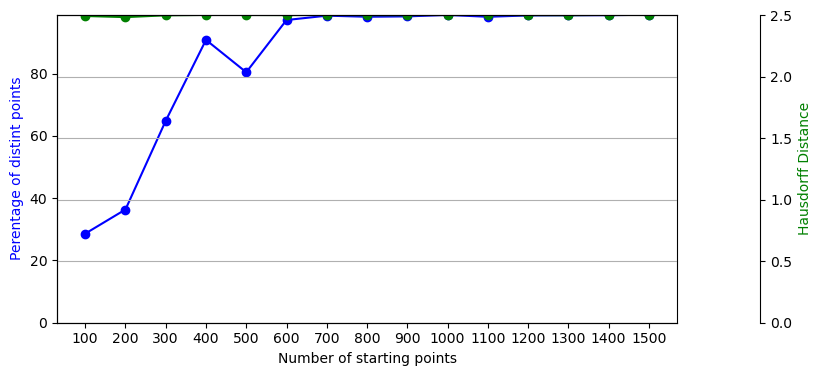

In [168]:
pdpeia, hdeia= get_values(folders)

In [169]:
for (p,h) in zip(pdpeia,hdeia):
    print(p, " * ", h)

28.599999999999998  *  2.495926522715942
36.35  *  2.486794174308214
64.83333333333333  *  2.5014000961764316
90.8  *  2.5046720794306263
80.42  *  2.5042150509660854
97.18333333333334  *  2.5033930079498248
98.58571428571429  *  2.5042486516751996
98.2375  *  2.502606518784179
98.35555555555555  *  2.5024738353303895
98.81  *  2.5062439469332163
98.22727272727273  *  2.503538441212521
98.65833333333333  *  2.503542001754361
98.71538461538462  *  2.502521154000698
98.73571428571428  *  2.5052011293009566
98.88666666666667  *  2.50393788406223


In [170]:
max(pdpeia), min(hdeia)

(98.88666666666667, 2.486794174308214)

In [171]:
#plot_solns(folders)

### Histograms

In [172]:
# n_runs= 50 and 
n_points= nubmer_points_list[np.argmax(pdpeia)]#1500
# Best
directory_path = "../EIA/solns_runs/Ex4/N_{}".format(n_points)
all_solnseia= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')

#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    all_solnseia.extend(solns.tolist())

all_solnseia= np.array(all_solnseia)

num, all_solnseia = count_repeated_points(all_solnseia)
all_solnseia= np.array(all_solnseia)

In [173]:
bins_list= [5, 10, 15, 20]
solns= all_solnseia.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 15-x
y_min = np.min(y)
y_max = np.max(y)
# y

# y

xeia= x.copy()
yeia= y.copy()

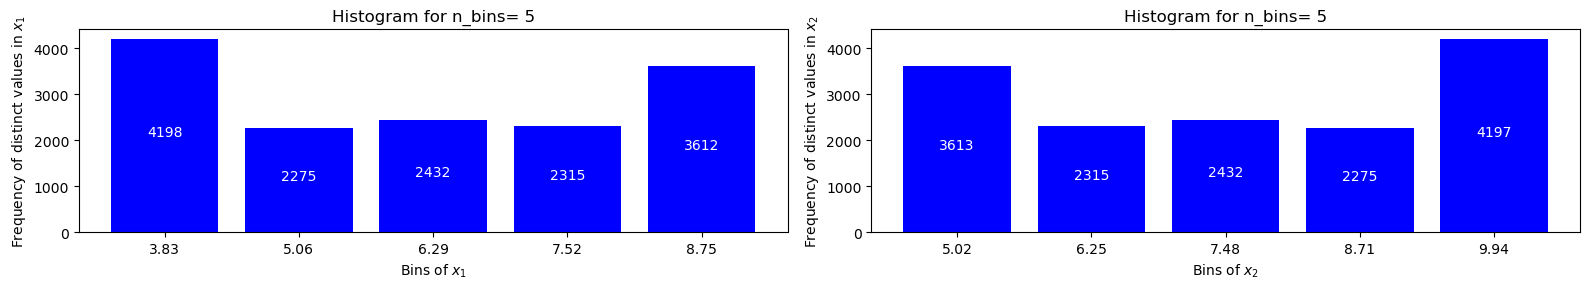

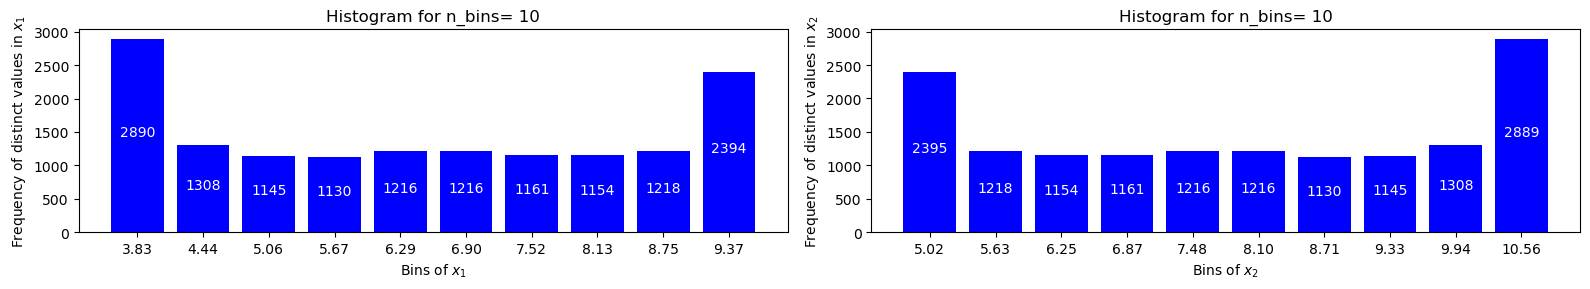

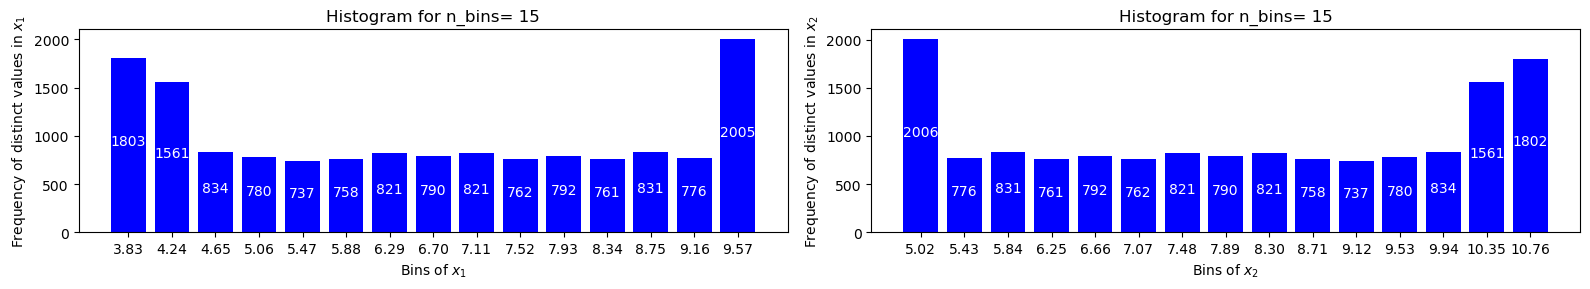

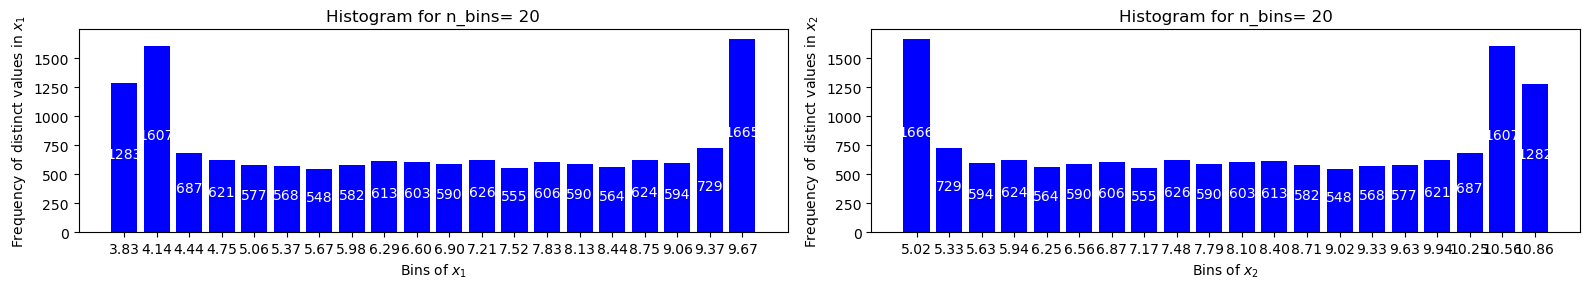

In [174]:
x_hist_eia= []
y_hist_eia= []
y_part_eia= []
x_part_eia= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_eia.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_eia.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_eia.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_eia.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../EIA/solns_runs/Ex4/'+'ex4_eia_hist'+str(n_bins)+'.png')
    plt.show()

### Uniform CDF vs. empirical CDF and  KS-Test

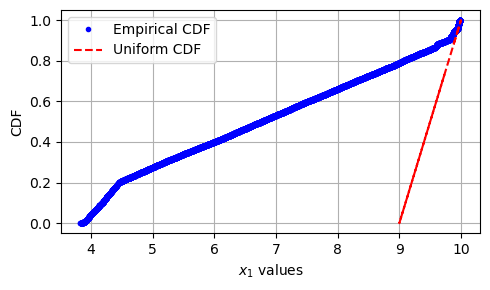

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [175]:
# KS Test on x: 
a,b= 9.0,10.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xeia)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xeia)
ecdf_eia_x = ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_x.x, ecdf_eia_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xeia, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

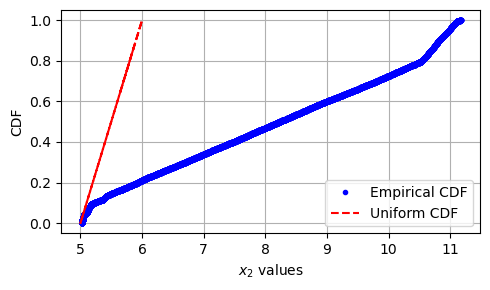

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [176]:
# KS Test on y: 
# Number of samples

a,b= 5.0, 6.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(xeia))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(yeia)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(yeia)
ecdf_eia_y = ECDF(yeia) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_eia_y.x, ecdf_eia_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../EIA/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(yeia, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

In [177]:
ks_statistic,p_value

(1.0, 0.0)

# SGD

In [178]:
main_path = "../SGD/solns_runs/Ex4/"
subfolders = list_subfolders(main_path)

    
txt_files = list_subfolders(subfolders[0])
# list_txt_files(subfolders[0])

titles = [str(100*i) for i in range(1, 16)]

colors = [
    'blue', 'orange', 'r', 'yellow', 'purple',
    'brown', 'pink', 'gray', 'olive', 'cyan', 'red',
    'lightcoral', 'darkgoldenrod', 'mediumseagreen', 'green', 'mangeta'
]

folders= ["../SGD/solns_runs/Ex4/N_{}/".format(str(pt)) for pt in nubmer_points_list]
folders

['../SGD/solns_runs/Ex4/N_100/',
 '../SGD/solns_runs/Ex4/N_200/',
 '../SGD/solns_runs/Ex4/N_300/',
 '../SGD/solns_runs/Ex4/N_400/',
 '../SGD/solns_runs/Ex4/N_500/',
 '../SGD/solns_runs/Ex4/N_600/',
 '../SGD/solns_runs/Ex4/N_700/',
 '../SGD/solns_runs/Ex4/N_800/',
 '../SGD/solns_runs/Ex4/N_900/',
 '../SGD/solns_runs/Ex4/N_1000/',
 '../SGD/solns_runs/Ex4/N_1100/',
 '../SGD/solns_runs/Ex4/N_1200/',
 '../SGD/solns_runs/Ex4/N_1300/',
 '../SGD/solns_runs/Ex4/N_1400/',
 '../SGD/solns_runs/Ex4/N_1500/']

## Number of starting points vs. PDP and HD

In [179]:
def get_values(folders):
    dist_= []
    avg_hd= []
    for pt in range(len(nubmer_points_list)):
        directory_path = folders[pt]

        files= list_txt_files_in_directory(directory_path)
        if len(files)>n_times:
            files= files[:n_times]
        res= []
        hd= []
        
        num_points= nubmer_points_list[pt]
        
        res_solns= []
        for file in files:
            
            if "._" in file:
                    file= file.replace("._","")
            
            solns= np.genfromtxt(file, delimiter=',')[:,:-1]
            #ask= solns[:,-1] <0.01
            #olns= solns[:,:-1][mask]
            res_solns.extend(solns.tolist())
        
        
        res_solns= np.array(res_solns)
        num, distinct_points = count_repeated_points(res_solns)
        distinct_points= np.array(distinct_points)
        
        # Get PDP
        
        dist_.append((len(distinct_points)/(len(res_solns)))*100)
        
        # Get HD:
        
        t_values = np.random.uniform(9.0, 10, len(distinct_points)-1)

        points = np.column_stack((t_values, 15 - t_values))
        points= np.vstack((points, np.array([5.0,9.0])))
        

        print(len(distinct_points), len(res_solns))
        hausdorff_distance = directed_hausdorff(distinct_points, points)[0]
        avg_hd.append(hausdorff_distance)
        
    # Create subplots with different scales
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # Create second axis with different scale
    ax1.set_xlabel('Number of starting points')
#     ax2 = ax1.twinx()
    ax1.set_ylim([0.0, np.max(dist_)])
    ax1.plot(nubmer_points_list, dist_, 'bo-')
    
#     ax1.set_yticks(dist_)
    
    ax1.set_ylabel('Perentage of distint points',color='blue')
#     ax1.set_ylabel('Perentage of distint points', color='b')


    # Create third axis with different scale
    ax2 = ax1.twinx()
    ax2.spines['right'].set_position(('outward', 60))  # Move the spine to the right
    ax2.plot(nubmer_points_list, avg_hd, 'go-')
    ax2.set_ylabel('Hausdorff Distance', color='g')
    ax2.set_ylim([0.0, np.max(avg_hd)])

    xticks = nubmer_points_list  # Precisely specify xticks from 0 to 10 with a step of 1
    ax1.set_xticks(xticks)
    ax1.set_xticklabels([f'{tick:.0f}' for tick in xticks])  # Format labels as strings with one decimal place


#     plt.savefig('./plots/Metrics/Ex1/ex1_gsm.jpeg')
    plt.savefig('../SGD/solns_runs/Ex4/plot_ex4.png')
# plt.xticks(list(range(len(possible_num_points))),possible_num_points)
    plt.grid(True)
    plt.show()

        
    return dist_,avg_hd

943 1000
1925 2000
2913 3000
3906 4000
4901 5000
5924 6000
6913 7000
7898 8000
8911 9000
9901 10000
10902 11000
11903 12000
12900 13000
13899 14000
14918 15000


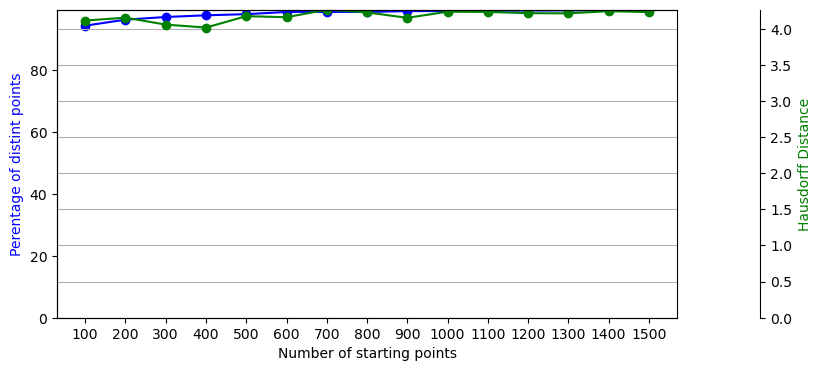

In [180]:
pdpsgd, hdsgd= get_values(folders)

In [181]:
for (p,h) in zip(pdpsgd,hdsgd):
    print(p, " * ", h)

94.3  *  4.113612778866068
96.25  *  4.153661308794674
97.1  *  4.057385210725907
97.65  *  4.0164598536168175
98.02  *  4.174423916116243
98.73333333333333  *  4.159752599712762
98.75714285714285  *  4.26354309018999
98.725  *  4.226753091130038
99.01111111111112  *  4.151128584043869
99.00999999999999  *  4.236340133064784
99.10909090909091  *  4.233080114124645
99.19166666666666  *  4.215839890995254
99.23076923076923  *  4.213499837643795
99.27857142857142  *  4.243624943867974
99.45333333333333  *  4.230701915325216


## Histograms

In [182]:
n_points= nubmer_points_list[np.argmax(pdpsgd)] # 1500
# Best
directory_path = "../SGD/solns_runs/Ex4/N_{}".format(n_points)
all_solnssgd= []

files= list_txt_files_in_directory(directory_path)
if len(files)>n_times:
    files= files[:n_times]
for file in files:
    if "._" in file:
        file= file.replace("._","")
    solns= np.genfromtxt(file, delimiter=',')[:,:-1]
    #mask= solns[:,-1]<0.01
    #solns= solns[:,:-1][mask]
#     num, distinct_points = count_repeated_points(solns)
#     distinct_points= np.array(distinct_points)
    
    all_solnssgd.extend(solns.tolist())

all_solnssgd= np.array(all_solnssgd)

num, all_solnssgd = count_repeated_points(all_solnssgd)
all_solnssgd= np.array(all_solnssgd)

In [183]:
## x:
bins_list= [5, 10, 15, 20]
solns= all_solnssgd.copy()
x= solns[:,0]
x_min = np.min(x)
x_max = np.max(x)

## y:
y= 15-x
y_min = np.min(y)
y_max = np.max(y)
# y

xsgd= x.copy()
ysgd= y.copy()

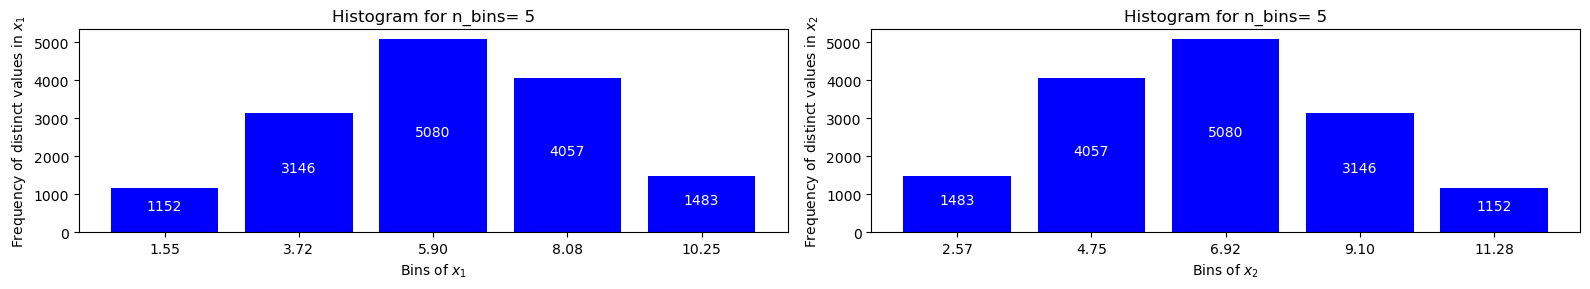

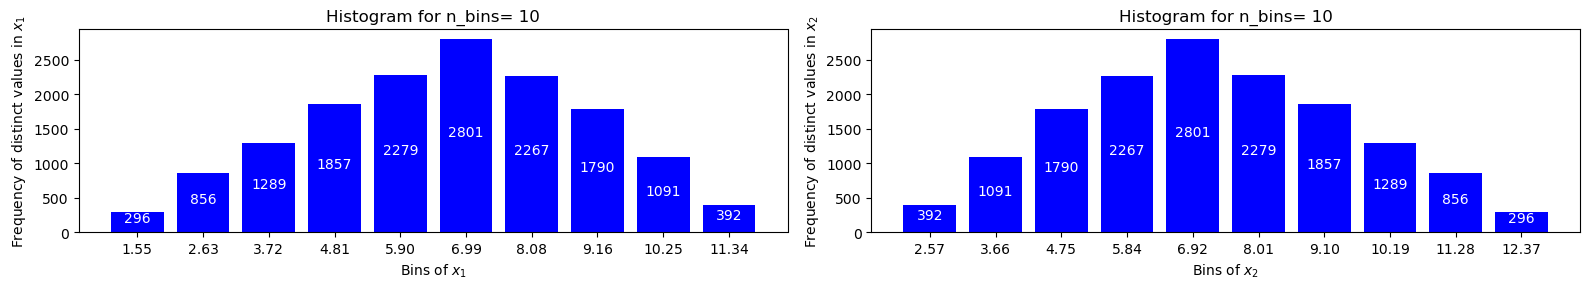

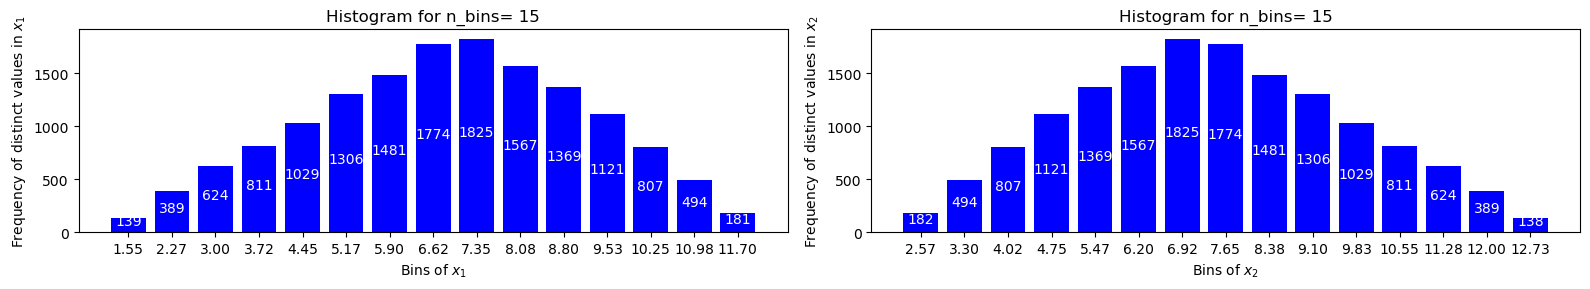

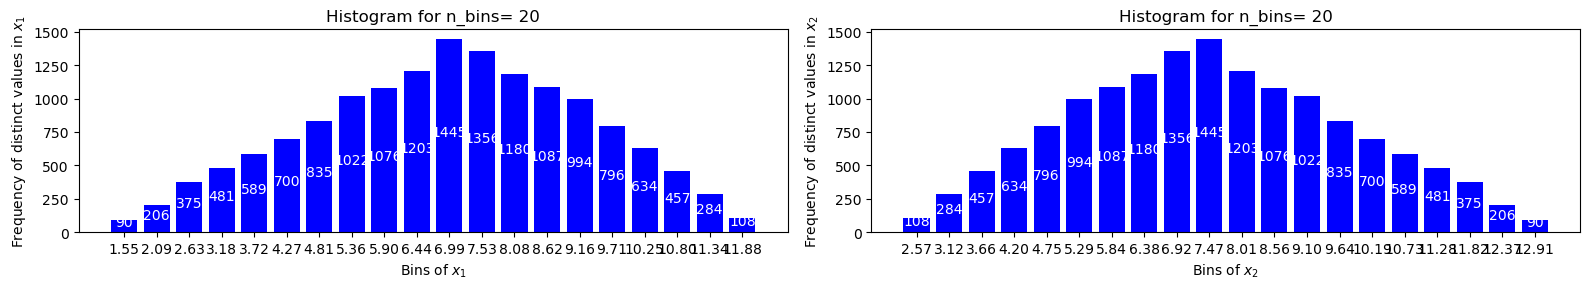

In [184]:
x_hist_sgd= []
y_hist_sgd= []
y_part_sgd= []
x_part_sgd= []
for n_bins in bins_list:
    partition_points = partition_interval(x_min, x_max, n_bins)
    x_part_sgd.append(partition_points)
#     print("Partition points:", partition_points)
    bin_counts = count_values_in_bins(x, partition_points)
    x_hist_sgd.append(bin_counts)
#     bin_counts= get_per(bin_counts)
#     print("Counts in each bin:", bin_counts)

    y_partition_points = partition_interval(y_min, y_max, n_bins)
    y_part_sgd.append(y_partition_points)
    y_bin_counts = count_values_in_bins(y, y_partition_points)
    y_hist_sgd.append(y_bin_counts)
    
#     y_bin_counts= get_per(y_bin_counts)
#     print("Counts in each bin:", y_bin_counts)


    plt.figure(figsize=(16, 3))

    plt.subplot(1, 2, 1)
    bars = plt.bar(range(len(bin_counts)), bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(bin_counts)), ["{:.2f}".format(b) for b in partition_points[:-1]])
    plt.xlabel('Bins of $x_1$')
    plt.ylabel('Frequency of distinct values in $x_1$')
    plt.title('Histogram for n_bins= {}'.format(len(bin_counts)))
#     plt.grid(True)

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(y_bin_counts)), y_bin_counts.values(), align='center', color='blue')

    # Annotate each bar with its frequency value
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2, str(int(y_bin_counts[i])), ha='center', color='white')

    # Customize plot
    plt.xticks(range(len(y_bin_counts)), ["{:.2f}".format(b) for b in y_partition_points[:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values in $x_2$')
    plt.title('Histogram for n_bins= {}'.format(len(y_bin_counts)))
#     plt.grid(True)
    plt.tight_layout()
    plt.savefig('../SGD/solns_runs/Ex4/'+'ex4_sgd_hist'+str(n_bins)+'.png')
    plt.show()

## Uniform CDF vs. empirical CDF and KS-Test

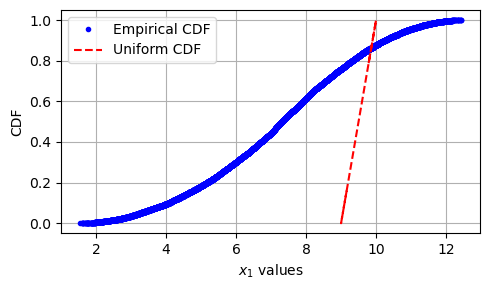

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [185]:
# KS Test on x: 
a,b= 9,10.
uniform_samples = np.random.uniform(low=a, high=b, size=len(xsgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

# Number of samples
n_samples = len(xsgd)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(xsgd)
ecdf_sgd_x = ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_x.x, ecdf_sgd_x.y, marker='.', linestyle='none', label='Empirical CDF',c= 'blue')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiric')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex4/ks_ex4_x1.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(xsgd, "uniform")#stats.kstest(ecdf.y, stats.uniform.cdf) #stats.kstest(ecdf.y, cdf_uniform)

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.") 

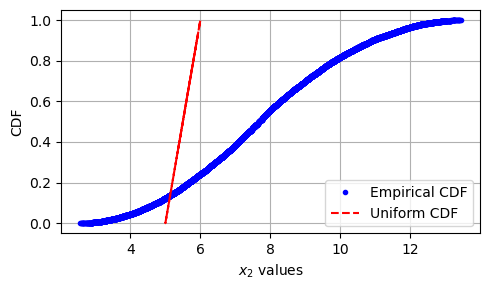

K-S Statistic: 1.0
P-Value: 0.0
Reject the null hypothesis: The sample does not follow the uniform distribution.


In [186]:
# KS Test on y: 
# Number of samples
a,b= 5, 6.0
uniform_samples = np.random.uniform(low=a, high=b, size=len(ysgd))
cdf_uniform= [get_cdf_of_uniform(i, a= a, b= b) for i in uniform_samples]

n_samples = len(ysgd)
plt.figure(figsize=(5, 3))

# CDF Plot
sorted_samples = np.sort(ysgd)
ecdf_sgd_y = ECDF(ysgd) # np.arange(1, n_samples+1) / n_samples
plt.plot(ecdf_sgd_y.x, ecdf_sgd_y.y, marker='.', linestyle='none', label='Empirical CDF', c= 'blue')
# plt.plot([1-1, 1-0.5], [1-1, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples, cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../SGD/solns_runs/Ex4/ks_ex4_x2.png')
plt.show()

# Perform K-S test
ks_statistic, p_value = stats.kstest(ysgd, "uniform")

# Display the results
print(f"K-S Statistic: {ks_statistic}")
print(f"P-Value: {p_value}")

# Decision based on the p-value
alpha = 0.05
if p_value > alpha:
    print("Fail to reject the null hypothesis: The sample follows the uniform distribution.")
else:
    print("Reject the null hypothesis: The sample does not follow the uniform distribution.")

# KS-Overall

In [187]:
def KS_test(sample, a, b, alpha=0.05):
    ecdf_sgd_x = ECDF(sample)
    x1 = ecdf_sgd_x.x       # First coordinate
    # ecdf_sgd_y = ECDF(ysgd)
    # x2 = ecdf_sgd_y.x   # Second coordinate
    # print("Algorithm ", name)
    ks_statistic, p_value = stats.kstest(sample, "uniform", args=(a, b-a))
    print(f"K-S Statistic: {ks_statistic:.4f}")
    print(f"P-Value: {p_value:.4f}")
    if p_value > alpha:
        print(f"Result: Fail to reject H0 → Sample follows Uniform({a},{b})\n")
    else:
        print(f"Result: Reject H0 → Sample does NOT follow Uniform({a},{b})\n")

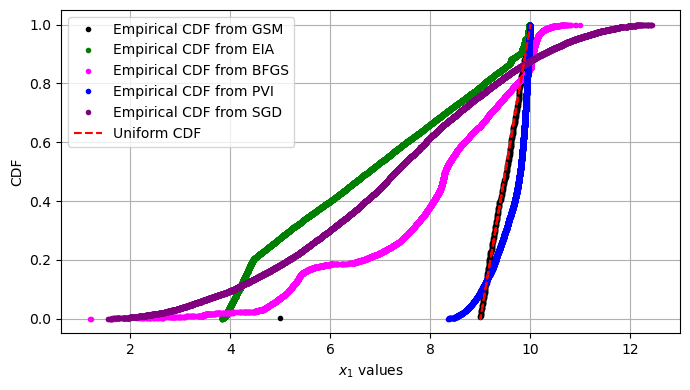

GSM
K-S Statistic: 0.7971
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(5.000004345875068,9.999999999996854)

*********
EIA
K-S Statistic: 0.0990
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(3.827383906905474,9.980658022558636)

*********
BFGS
K-S Statistic: 0.3716
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(1.1837716660232083,10.997846000830322)

*********
PVI
K-S Statistic: 0.4124
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(8.344960780936438,9.999941646668189)

*********
SGD
K-S Statistic: 0.1366
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(1.546676350237069,12.428771185973275)

*********


In [188]:
# KS Test on x: 
a1,b1= 9,10
uniform_samples = np.random.uniform(low=a1, high=b1, size=len(x))
#uniform_samples= np.hstack((uniform_samples,5))
cdf_uniform= [get_cdf_of_uniform(i, a= a1, b= b1) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(x)
ecdfgsm= ECDF(xgsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(xeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(xbfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(xpvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(xsgd) #np.arange(1, n_samples+1) / n_samples

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_1$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex4/all_ks_ex4_x1.png')
plt.show()

#KS_Test(xgsm, algo= "GSM")
#KS_Test(xeia, algo= "EIA")
#KS_Test(xbfgs, algo= "BFGS")
#KS_Test(data, algo= "PVI")
#KS_Test(data, algo= "SGD")

print("GSM")
KS_test(xgsm, min(xgsm), max(xgsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(xeia, min(xeia), max(xeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(xbfgs, min(xbfgs), max(xbfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(xpvi, min(xpvi), max(xpvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(xsgd, min(xsgd), max(xsgd), alpha=0.05)
print("*********")

In [189]:
# ecdfeia.x,ecdfbfgs.x

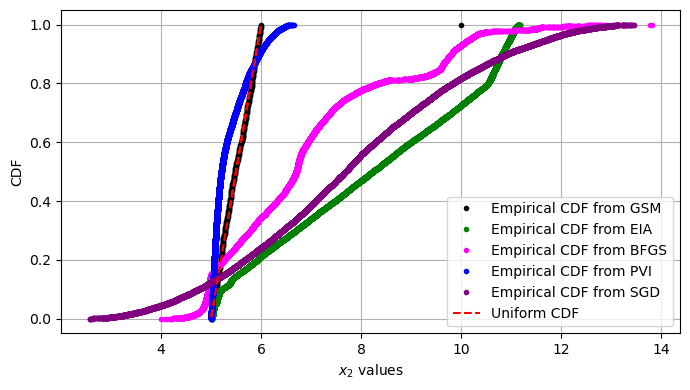

GSM
K-S Statistic: 0.7971
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(5.000000000003146,9.999995654124932)

*********
EIA
K-S Statistic: 0.0990
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(5.019341977441364,11.172616093094526)

*********
BFGS
K-S Statistic: 0.3716
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(4.002153999169678,13.816228333976792)

*********
PVI
K-S Statistic: 0.4124
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(5.000058353331811,6.655039219063562)

*********
SGD
K-S Statistic: 0.1366
P-Value: 0.0000
Result: Reject H0 → Sample does NOT follow Uniform(2.5712288140267248,13.45332364976293)

*********


In [190]:
# KS Test on y: 
# Number of samples
a2,b2= 5,6
uniform_samples = np.random.uniform(low=a2, high=b2, size=len(x))
# uniform_samples= np.hstack((uniform_samples,9))
cdf_uniform= [get_cdf_of_uniform(i, a= a2, b= b2) for i in uniform_samples]

# Number of samples
n_samples = len(x)

# Generate uniform values in [0,1]
#uniform_samples = np.random.uniform(low=0.0, high=1.0, size=n_samples)

# Plotting the histogram of uniform samples
plt.figure(figsize=(7, 4))

# CDF Plot
sorted_samples = np.sort(y)
ecdfgsm= ECDF(ygsm) #np.arange(1, n_samples+1) / n_samples
ecdfeia= ECDF(yeia) #np.arange(1, n_samples+1) / n_samples
ecdfbfgs= ECDF(ybfgs) #np.arange(1, n_samples+1) / n_samples
ecdfpvi= ECDF(ypvi) #np.arange(1, n_samples+1) / n_samples
ecdfsgd= ECDF(ysgd)

plt.plot(ecdfgsm.x, ecdfgsm.y, marker='.', linestyle='none', label='Empirical CDF from GSM',c= 'black')
plt.plot(ecdfeia.x, ecdfeia.y, marker='.', linestyle='none', label='Empirical CDF from EIA',c= 'green')
plt.plot(ecdfbfgs.x, ecdfbfgs.y, marker='.', linestyle='none', label='Empirical CDF from BFGS',c= 'magenta')

plt.plot(ecdfpvi.x, ecdfpvi.y, marker='.', linestyle='none', label='Empirical CDF from PVI',c= 'blue')
plt.plot(ecdfsgd.x, ecdfsgd.y, marker='.', linestyle='none', label='Empirical CDF from SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
plt.plot(uniform_samples,cdf_uniform, 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('$x_2$ values')
plt.ylabel('CDF')
# plt.xlim([0, 1])
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex4/all_ks_ex4_x2.png')
plt.show()


print("GSM")
KS_test(ygsm, min(ygsm), max(ygsm), alpha=0.05)
print("*********")
print("EIA")
KS_test(yeia, min(yeia), max(yeia), alpha=0.05)
print("*********")
print("BFGS")
KS_test(ybfgs, min(ybfgs), max(ybfgs), alpha=0.05)
print("*********")
print("PVI")
KS_test(ypvi, min(ypvi), max(ypvi), alpha=0.05)
print("*********")
print("SGD")
KS_test(ysgd, min(ysgd), max(ysgd), alpha=0.05)
print("*********")
# KS_Test(ygsm, algo= "GSM")
# KS_Test(yeia, algo= "EIA")
# # KS_Test(ybfgs, algo= "BFGS")
# # KS_Test(data, algo= "PVI")
# # KS_Test(data, algo= "SGD")

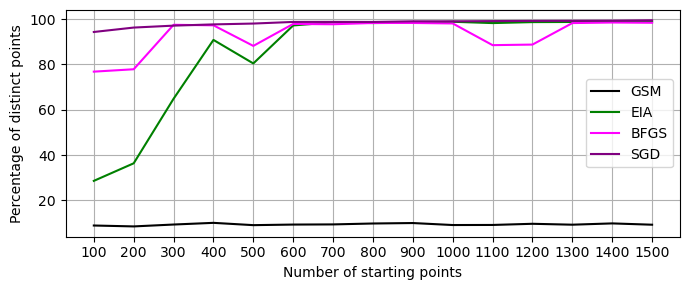

In [191]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, pdpgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, pdpeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, pdpbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, pdppvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, pdpsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Percentage of distinct points')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex4/ex4_npoints_pdp.png')
plt.show()

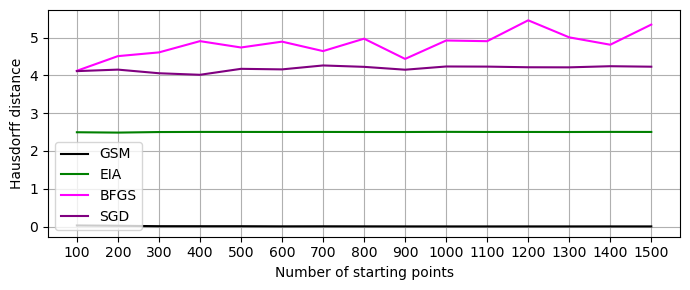

In [192]:
plt.figure(figsize=(7, 3))
plt.plot(nubmer_points_list, hdgsm,label='GSM',c= 'black')
plt.plot(nubmer_points_list, hdeia, label='EIA',c= 'green')
plt.plot(nubmer_points_list, hdbfgs, label='BFGS',c= 'magenta')

# plt.plot(nubmer_points_list, hdgpvi, label='PVI',c= 'blue')
plt.plot(nubmer_points_list, hdsgd, label='SGD',c= 'purple')
# plt.plot([0.5, 1], [0.0, 1], 'r--', label='Uniform CDF')
# plt.title('CDF of Uniform Samples vs. Empiricc')
plt.xlabel('Number of starting points')
plt.ylabel('Hausdorff distance')
plt.xticks(nubmer_points_list)
# plt.ylim([0, 1])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../KS-Plots/Ex4/ex4_npoints_hd.png')
plt.show()

# Histograms

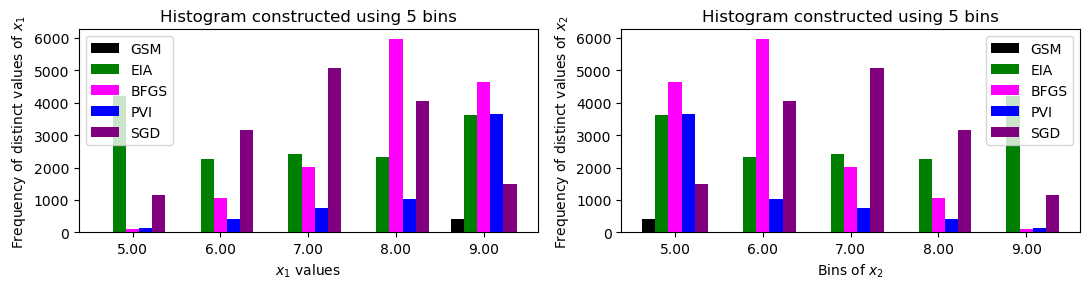

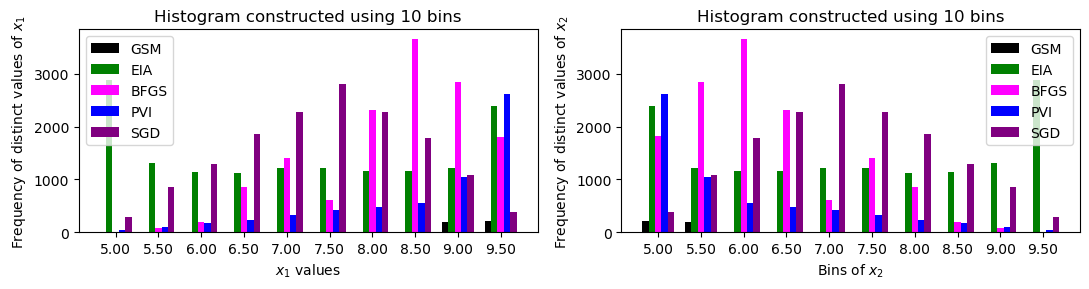

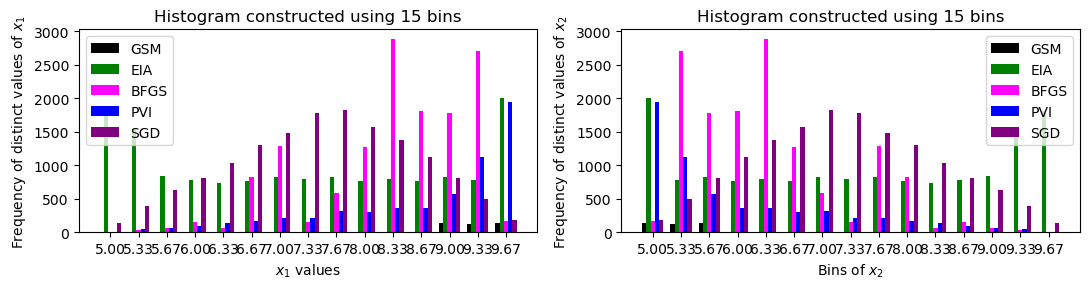

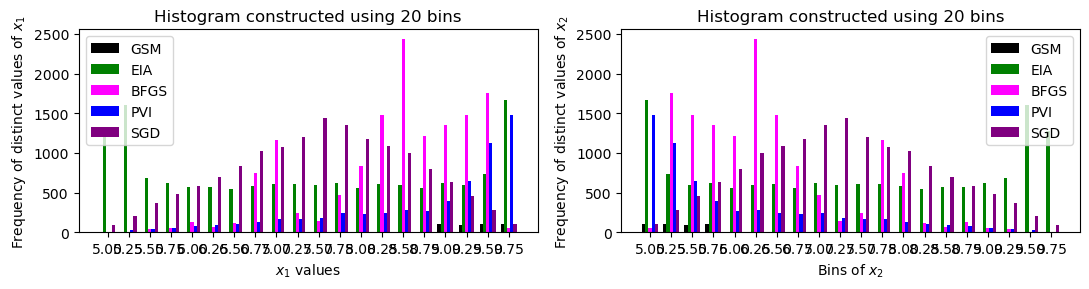

In [193]:
import matplotlib.pyplot as plt
import numpy as np

for n_bins in range(len(bins_list)):
    plt.figure(figsize=(11, 3))  # Increase the figure height for better readability
    
    width = 0.15  # Width of the bars
    
    # First subplot for x_hist_gsm and x_hist_eia
    plt.subplot(1, 2, 1)
    
    x = np.arange(len(x_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(x - 2*width, list(x_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(x - width, list(x_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(x, list(x_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(x + width, list(x_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(x + 2*width, list(x_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')
    
    # Customize plot
    plt.xticks(x, ["{:.2f}".format(b) for b in x_part_gsm[n_bins][:-1]])
    plt.xlabel('$x_1$ values')
    plt.ylabel('Frequency of distinct values of $x_1$')
    plt.title('Histogram constructed using {} bins'.format(len(x_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.legend(loc='upper right')
#     plt.grid(True)
    
    # Second subplot for y_hist_gsm and y_hist_eia
    plt.subplot(1, 2, 2)
    
    y = np.arange(len(y_hist_gsm[n_bins]))  # X locations for the groups
    
    barsgsm = plt.bar(y - 2*width, list(y_hist_gsm[n_bins].values()), width, align='center', color='black', label='GSM')
    barseia = plt.bar(y - width, list(y_hist_eia[n_bins].values()), width, align='center', color='green', label='EIA')
    barsbfgs = plt.bar(y, list(y_hist_bfgs[n_bins].values()), width, align='center', color='magenta', label='BFGS')
    barspvi = plt.bar(y + width, list(y_hist_pvi[n_bins].values()), width, align='center', color='blue', label='PVI')
    barssgd = plt.bar(y + 2*width, list(y_hist_sgd[n_bins].values()), width, align='center', color='purple', label='SGD')

    # Customize plot
    plt.xticks(y, ["{:.2f}".format(b) for b in y_part_gsm[n_bins][:-1]])
    plt.xlabel('Bins of $x_2$')
    plt.ylabel('Frequency of distinct values of $x_2$')
    plt.title('Histogram constructed using {} bins'.format(len(y_hist_gsm[n_bins])))
    plt.legend(loc='best', frameon=True, shadow=False)
    #plt.legend(loc='upper right')
#     plt.grid(True)
    
    plt.tight_layout()
    # Uncomment the next line to save the plot
    plt.savefig('../KS-Plots/Ex4/'+'ex4_hist_bin'+str(bins_list[n_bins])+'.png')
    plt.show()


In [194]:
Ex4Sols= {
        "EIA":
                {
                    "hd": None, "pdp": None, "solutions": None
                },

     "SGD":{
        "hd":None, "pdp": None, "solutions":None
    },

     "GSM":{
        "hd":None, "pdp": None, "solutions":None
    },

     "PVI":{
        "hd":None, "pdp": None, "solutions":None
    },

     "BFGS":{
        "hd":None, "pdp": None, "solutions":None
    }



}

In [195]:
Algorithms= ["EIA", "SGD", "GSM", "PVI", "BFGS"]

HDResults= [hdeia, hdsgd, hdgsm, hdgpvi, hdbfgs]
PDPResults= [pdpeia, pdpsgd, pdpgsm, pdppvi, pdpbfgs]
# dataSol= [data_eia, data_sgd, data_gsm, data_pvi, data_bfgs]

In [196]:
for (idx, algo) in enumerate(Algorithms):

    Ex4Sols[algo]["hd"]= HDResults[idx]
    Ex4Sols[algo]["pdp"]= PDPResults[idx]
    # Ex4Sols[algo]["solutions"]= dataSol[idx]

In [197]:
import json

def convert_ndarray(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Object of type {type(obj)} is not JSON serializable")

with open("Ex4Sols.json", "w", encoding="utf-8") as f:
    json.dump(Ex4Sols, f, indent=4, default=convert_ndarray)

In [198]:
import json

with open("Ex4Sols.json", "r", encoding="utf-8") as f:
    Ex4Sols_loaded = json.load(f)

